# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [5]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

pd.set_option('display.max_columns', None)

## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [2]:
proteins_df = pg.merge_resources(rows_per_id=None)
proteins_df

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
0,UPI0000D62424,UPI0000D62424,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0000D62424,NaN,NaN,NaN,NaN
1,NP_036345.2,NP_036345,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_036345.2,MLYCD,ENSG00000103150,ENST00000262430,ENSP00000262430
2,NP_036196.1,NP_036196,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_036196.1,MIP,ENSG00000135517,ENST00000257979,ENSP00000257979
3,NP_116027.2,NP_116027,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_116027.2,GATA2,ENSG00000179348,ENST00000341105,ENSP00000345681
4,NP_008880.2,NP_008880,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_008880.2,STXBP2,ENSG00000076944,ENST00000441779,ENSP00000413606
...,...,...,...,...,...,...,...,...,...
4774,NP_000012.1,NP_000012,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000012.1,PSEN1,ENSG00000080815,ENST00000557293,ENSP00000451880
4775,NP_000012.1,NP_000012,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000012.1,PSEN1,ENSG00000080815,ENST00000394157,ENSP00000377712
4776,NP_000012.1,NP_000012,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000012.1,PSEN1,ENSG00000080815,ENST00000324501,ENSP00000326366
4777,NP_001098101.1,NP_001098101,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001098101.1,PDE4D,ENSG00000113448,ENST00000340635,ENSP00000345502


In [3]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins['protein'] = candidate_proteins['RefSeq Protein']
# candidate_proteins = er.map_ids(df=candidate_proteins,
#                                 input_col="RefSeq Protein")
candidate_proteins = pg.map_resources(df=candidate_proteins)
candidate_proteins

Mapping Proteingym IDs
Loading mapping file from /home/schilder/.cache/ProteinGym/proteingym_id_map_693de35055033c431bc1452512841718.csv.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,RefSeq Protein Stable,protein,genename,ENSG,ENST,ENSP
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,NP_001346945.1,NaN,NaN,NaN,NaN
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,NP_000401,NP_000401.1,HFE,ENSG00000010704,ENST00000357618,ENSP00000417404
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,NP_000483,NP_000483.3,CFTR,ENSG00000001626,ENST00000003084,ENSP00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283
4,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000352993,ENSP00000312236
5,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,NP_000050,NP_000050.3,NaN,NaN,NaN,NaN
6,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,NP_000121,NP_000121.2,F5,ENSG00000198734,ENST00000367797,ENSP00000356771
7,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,NP_000509,NP_000509.1,HBB,ENSG00000244734,ENST00000335295,ENSP00000333994
8,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,NP_000286,NP_000286.3,SERPINA1,ENSG00000197249,ENST00000440909,ENSP00000390299
9,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,NP_000518,NP_000518.1,LDLR,ENSG00000130164,ENST00000558518,ENSP00000454071


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [4]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "union",
                                         use_deepcopy = True) 

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/2503 [00:00<?, ?it/s]

Using deepcopy
Merging 2847 tx_ids using union


Merging haplotype datasets: 0it [00:00, ?it/s]

Merging haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Merged 132721 haplotypes across 2847 tx_ids.


Plot the number of haplotypes per protein, as well as the number of WT variants per haplotype.

Adding reference haplotype:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to dataframe:   0%|          | 0/2847 [00:00<?, ?it/s]

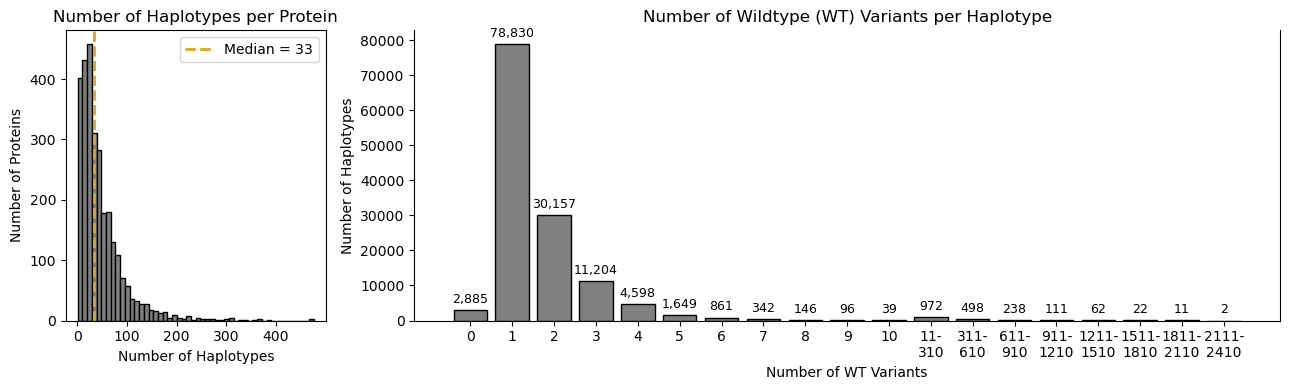

In [12]:
hs.plot_haplotypes_summary(haplotypes)

Map haplotypes back to samples (individuals).

In [11]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 2847


Processing sample to haplotype name maps:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (19262867, 16)
>> haplotype(s): 132721
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2


,ENST_haplosaurus,cohort_sample,haplotype,cohort,sample,ploid_count,ploid,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections,population_code
0,ENST00000001146,1000GENOMES:phase_3:HG00133,ENSP00000001146:REF,1000GENOMES,HG00133,2,0,female,SAME123062,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
1,ENST00000001146,1000GENOMES:phase_3:HG00133,ENSP00000001146:REF,1000GENOMES,HG00133,2,1,female,SAME123062,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
2,ENST00000001146,1000GENOMES:phase_3:HG00598,ENSP00000001146:REF,1000GENOMES,HG00598,2,0,male,SAME1839713,CHS,Southern Han Chinese,EAS,East Asian Ancestry,CHS,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
3,ENST00000001146,1000GENOMES:phase_3:HG00598,ENSP00000001146:REF,1000GENOMES,HG00598,2,1,male,SAME1839713,CHS,Southern Han Chinese,EAS,East Asian Ancestry,CHS,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
4,ENST00000001146,1000GENOMES:phase_3:HG00290,ENSP00000001146:REF,1000GENOMES,HG00290,2,0,male,SAME1839057,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN


Infer per-superpopulation haplotype frequencies from the haplotype-sample maps.
--- 


For each haplotype, `calculate_haplotype_frequency_per_superpop()` assigns a:
- `***_freq`: The frequency at which the haplotype occurs in each superopulation.
- `***_samples`: The number of samples in which the haplotype occurs in each superopulation.
- `top_superpopulation`: The superpopulation in which the haplotype occurred most frequently.
- `top_superpopulation_freq`: The frequency at which the happlotype occurs in the `top_superpopulation`.
- `superpopulation_count`: The number of unique superpopulations in which the haplotype occurs.
- `specific_superpopulation`: If the haplotype only occurred in one superopulation, this column is filled with its name. 
- `specific_superpopulation_samples`: If the haplotype only occurred in one superopulation, this column is filled with the number of samples from that superpopulation. 

*NOTE*: In this case, each individual has two "samples" (one per haplotype).

In [151]:
freq_df.to_parquet("results/data/freq_df.parquet")

In [ ]:
freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
# freq_df.to_parquet("results/data/freq_df.parquet")
freq_df.head()

0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    35540
EAS    22458
EUR    14917
SAS    13574
AMR     9224
CSA     5134
MID     4439
OCE     1850
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 80.72%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000001146:110H>Y,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0
1,"ENSP00000001146:119R>H,264L>S",2.054751e-06,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,2.054751e-06,1,AFR,12.0
2,ENSP00000001146:123M>V,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,1.240141e-06,1,MID,1.0
3,"ENSP00000001146:140N>I,380E>K",0.000000e+00,0.0,0.0,2.738582e-07,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,EAS,2.738582e-07,1,EAS,1.0
4,ENSP00000001146:143K>R,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0


### Create Upset plot

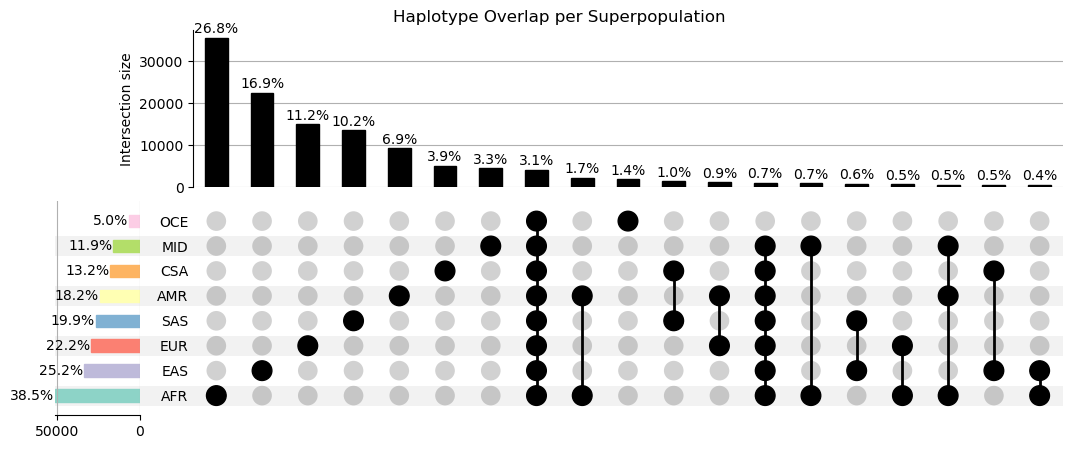

In [149]:
upset, counts_df = hs.plot_superpop_upset(freq_df)

In [ ]:
if 'specific_superpopulation' not in locals():
    specific_superpopulation = freq_df['specific_superpopulation'].copy()
freq_df.loc[freq_df['specific_superpopulation_samples']< 2, "specific_superpopulation"] = pd.NA 

Plot the number of samples per superpopulation, as well as whether each haplotype is specific to one superpopulation.

Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

0 samples are missing superpopulation metadata


<string>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


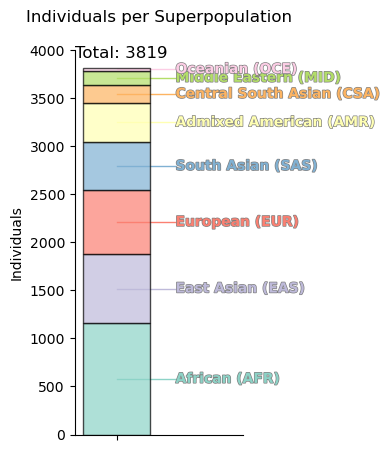

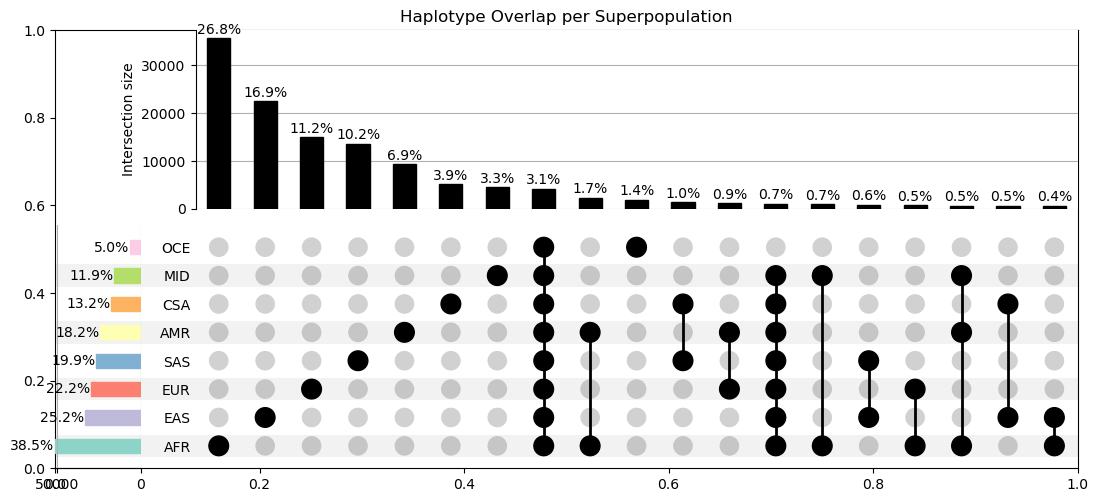

In [146]:
plot_haplotypes_and_superpop_bar_out = hs.plot_haplotypes_and_superpop_bar(freq_df,
                                                                  haplotypes,
                                                                 width_ratios=(.2,1), figsize=(13,5))

`filter_prot_df` provides a convenient way to filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data,   
as well as which ones are present in the candidate proteins.

It will automatically figure out which `proteins_df` columns in it should be filtering on according to the prefixes in the `protein_ids` ('ENSP' or 'ENST' or 'protein') and `haplotypes` ('ENSP' or 'ENST').

It can also filter by the types of mutations you wish to inject during the VEP procedure (see the 'source_type' column for available options).

The final product is the filtered `proteins_df`, which we store as a new DataFrame `prot_df`.

In [6]:
prot_df = vp.filter_prot_df(proteins_df,
#                             protein_ids=candidate_proteins["ENSP"],
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            )
prot_df

Filtering by 1 source types
Filtering by ENST haplotypes


Getting haplotype sequences:   0%|          | 0/557 [00:00<?, ?it/s]

  0%|          | 0/557 [00:00<?, ?it/s]

Filtered 10 / 192 proteins due to sequence length mismatch
Returning 182 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
18,NP_004437.2,NP_004437,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004437.2,EPRS,ENSG00000136628,ENST00000366923,ENSP00000355890,[1512],[1512],1.0,True
40,NP_065873.2,NP_065873,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_065873.2,KCNT1,ENSG00000107147,ENST00000371757,ENSP00000360822,[1235],[1235],1.0,True
44,NP_115791.3,NP_115791,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_115791.3,CARD11,ENSG00000198286,ENST00000396946,ENSP00000380150,[1154],[1154],1.0,True
58,NP_004619.3,NP_004619,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004619.3,XPC,ENSG00000154767,ENST00000285021,ENSP00000285021,[940],[940],1.0,True
103,NP_060269.3,NP_060269,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060269.3,TMEM260,ENSG00000070269,ENST00000261556,ENSP00000261556,[707],[707],1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4653,NP_002520.2,NP_002520,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002520.2,NTRK1,ENSG00000198400,ENST00000524377,ENSP00000431418,[796],[796],1.0,True
4686,NP_000084.3,NP_000084,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000084.3,COL5A1,ENSG00000130635,ENST00000371817,ENSP00000360882,[1838],[1838],1.0,True
4701,NP_000144.2,NP_000144,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000144.2,GALC,ENSG00000054983,ENST00000261304,ENSP00000261304,[685],[685],1.0,True
4703,NP_000292.1,NP_000292,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000292.1,PLG,ENSG00000122194,ENST00000308192,ENSP00000308938,[810],[810],1.0,True


We also need to remove any suspicious proteins that have a different reference sequence lengths in the Haplosaurus haplotypes and the ProteinGym mutations   
(which suggests that the ProteinGym proteins are not exactly the same as the Haplosaurus ones).

In [7]:
prot_df = vp.add_sequence_checks(prot_df,
                                  haplotypes=haplotypes)
prot_df = prot_df.loc[prot_df['proteingym_haplosaurus_seq_identical'] == True]
prot_df

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
18,NP_004437.2,NP_004437,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004437.2,EPRS,ENSG00000136628,ENST00000366923,ENSP00000355890,[1512],[1512],1.0,True
40,NP_065873.2,NP_065873,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_065873.2,KCNT1,ENSG00000107147,ENST00000371757,ENSP00000360822,[1235],[1235],1.0,True
44,NP_115791.3,NP_115791,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_115791.3,CARD11,ENSG00000198286,ENST00000396946,ENSP00000380150,[1154],[1154],1.0,True
58,NP_004619.3,NP_004619,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004619.3,XPC,ENSG00000154767,ENST00000285021,ENSP00000285021,[940],[940],1.0,True
103,NP_060269.3,NP_060269,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060269.3,TMEM260,ENSG00000070269,ENST00000261556,ENSP00000261556,[707],[707],1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4653,NP_002520.2,NP_002520,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002520.2,NTRK1,ENSG00000198400,ENST00000524377,ENSP00000431418,[796],[796],1.0,True
4686,NP_000084.3,NP_000084,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000084.3,COL5A1,ENSG00000130635,ENST00000371817,ENSP00000360882,[1838],[1838],1.0,True
4701,NP_000144.2,NP_000144,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000144.2,GALC,ENSG00000054983,ENST00000261304,ENSP00000261304,[685],[685],1.0,True
4703,NP_000292.1,NP_000292,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000292.1,PLG,ENSG00000122194,ENST00000308192,ENSP00000308938,[810],[810],1.0,True


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [8]:
vp.list_models(as_list=False)

Available models:
- esm1_t12_85M_UR50S
- esm1_t34_670M_UR100
- esm1_t34_670M_UR50D
- esm1_t34_670M_UR50S
- esm1_t6_43M_UR50S
- esm1b_t33_650M_UR50S
- esm1v_t33_650M_UR90S
- esm1v_t33_650M_UR90S_1
- esm1v_t33_650M_UR90S_2
- esm1v_t33_650M_UR90S_3
- esm1v_t33_650M_UR90S_4
- esm1v_t33_650M_UR90S_5
- esm2
- esm2_t12_35M_UR50D
- esm2_t30_150M_UR50D
- esm2_t33_650M_UR50D
- esm2_t36_3B_UR50D
- esm2_t48_15B_UR50D
- esm2_t6_8M_UR50D
- esm_if1_gvp4_t16_142M_UR50
- esm_msa1_t12_100M_UR50S
- esm_msa1b_t12_100M_UR50S
- esmfold_structure_module_only_150M
- esmfold_structure_module_only_150M_270K
- esmfold_structure_module_only_15B
- esmfold_structure_module_only_35M
- esmfold_structure_module_only_35M_270K
- esmfold_structure_module_only_3B
- esmfold_structure_module_only_3B_270K
- esmfold_structure_module_only_650M
- esmfold_structure_module_only_650M_270K
- esmfold_structure_module_only_8M
- esmfold_structure_module_only_8M_270K
- esmfold_v0
- esmfold_v1


Run VEP pipeline and store the results in `save_dir`.

In [ ]:
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import src.vep_pipeline as vp 
import src.haplosaurus as hs
import torch
torch.cuda.set_device("cuda:0")

save_paths = vp.vep_pipeline(
    # hap_dir = hs.DIR_DICT["HGDP_haplotypes"],
    # prot_df = prot_df,
    # haplotypes = haplotypes, 
    models = [
        # "esm1_t6_43M_UR50S",
          # "esm1_t34_670M_UR50D",
          # "esm1v_t33_650M_UR90S_1",
          # "esm1b_t33_650M_UR50S",
        #   "esm2_t12_35M_UR50D",
        #   "esm2_t33_650M_UR50D",
        #   "esm2_t36_3B_UR50D"
        #   "esm2_t48_15B_UR50D",
      # "esmfold_v1",
            # "esm3_sm_open_v1",
            "esmc_600m"
             ],
    scoring_strategies = [
        # "wt-marginals", 
        # "masked-marginals",
        "masked-marginals",
        # "pseudo-ppl" # Takes much longer to run
        ],
    enable_data_parallel=False,
    source_types = ["clinical_ProteinGym_substitutions"],
    verbose = False
)

print(len(save_paths),"results files generated.")

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

### Merge VEP results files
Merge individual VEP files into one large dataframe.

In [16]:
vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 971261 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 8
scoring_strategy: 3
variant_set: 1
haplotype: 111561
protein: 2251


Gather all VEP results for each model and save as one parquet each.

In [1]:
# for model_location in vep_files["model_location"].unique():
#     print(model_location)
#     save_path = f"results/data/vep_df_{model_location}.parquet"
#     if os.path.exists(save_path):
#         print(f"Skipping {model_location} because it already exists")
#         continue
#     vep_df = va.merge_vep(add_metadata=False, 
#                           vep_files=vep_files[vep_files["model_location"] == model_location],
#                           scoring_strategy=["masked-marginals"])
#     vep_df.to_parquet(save_path)

...Or download a subset of the data for just one model.

### Check whether the VEP is affected by whether the variant is already in the haplotype

ValueError: Could not interpret value `VEP` for `y`. An entry with this name does not appear in `data`.

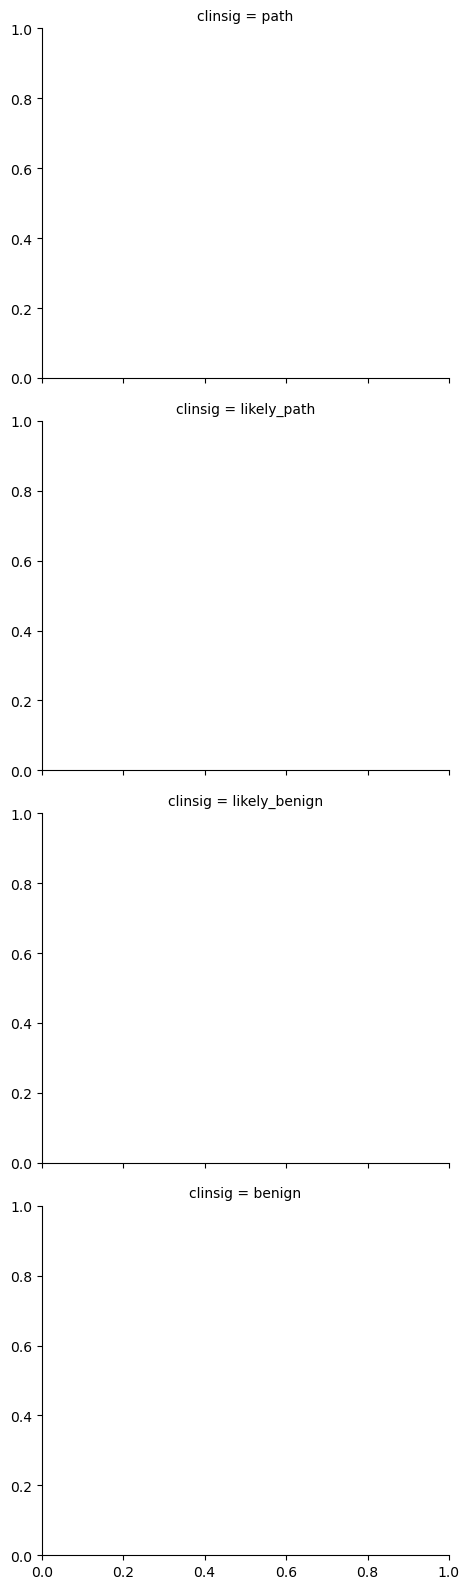

In [8]:
import seaborn as sns

vep_df = utils.sort_by_clinsig(vep_df)
g = sns.FacetGrid(data=vep_df, 
                   row='clinsig',    
                   sharey=False,
                   height=4, aspect=1.2)
g.map_dataframe(sns.violinplot, 
                x='mutant_in_haplotype', 
                y='VEP',
                hue='clinsig',
                palette=utils.get_clinsig_palette())
g.tight_layout()

### Check out of frame mutants

These should all be filtered out automatically by the vep_pipeline, but just to check.

In [9]:
# Import haplotypes if not already defined
if 'haplotypes' not in locals():
    haplotypes = hs.get_haplotypes(
        tx_ids=vep_df['ENST'].unique().tolist(),
        cache_only=True
    )

# Add haplotype sequences to the VEP dataframe
vep_df = va.add_mutant_out_of_frame(vep_df, 
                                    haplotypes=haplotypes,
                                    force=True)


# Check if any haplotypes with variants that are out of frame
print(vep_df.loc[vep_df['mutant_out_of_frame']==True]['haplotype'].unique().tolist()[:10])


# Filter out variants that are out of frame, as they should not not be able to produce a VEP
# vep_df = vep_df.loc[vep_df['mutant_out_of_frame']==False]
vep_df.head()

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/2 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Getting haplotype sequences


Adding reference haplotype:   0%|          | 0/2 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Adding 'haplotype_sequence_len' column
Adding 'mutant_out_of_frame' column
[]


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,ESM3,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame
15,ENSP00000419153:REF,NP_001157814.1,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,R613C,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,Pathogenic,-5.562500,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000419153,NaN,False,3,114339394,638658,G,A,.,PASS,638658,3:114339394,A,26137,NM_001164342.2,Transcript,missense_variant,2017,1837,613,R/C,Cgc/Tgc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_001164342.2:c.1837C>T,NP_001157814.1:p.Arg613Cys,-,NaN,NaN,626436,"MONDO:MONDO:0009798,MedGen:C0796121,OMIM:25905...",Primrose_syndrome,NC_000003.12:g.114339394G>A,"criteria_provided,_single_submitter",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,ZBTB20:26137,"SO:0001583|missense_variant,SO:0001619|non-cod...",32,1576220876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-12.031578,-0.025690,4,path,NaN,741,NaN,NaN,False
17,ENSP00000419153:REF,NP_001157814.1,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,H606R,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,Pathogenic,-6.984375,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000419153,NaN,False,3,114339414,1686308,T,C,.,PASS,1686308,3:114339414,C,26137,NM_001164342.2,Transcript,missense_variant,1997,1817,606,H/R,cAc/cGc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_001164342.2:c.1817A>G,NP_001157814.1:p.His606Arg,-,NaN,NaN,1678316,"MONDO:MONDO:0009798,MedGen:C0796121,OMIM:25905...",Primrose_syndrome,NC_000003.12:g.114339414T>C,"criteria_provided,_single_submitter",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,ZBTB20:26137,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-14.310934,-0.020886,4,path,NaN,741,NaN,NaN,False
18,ENSP00000419153:REF,NP_001157814.1,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,H606P,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,Pathogenic,-9.187500,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000419153,NaN,False,3,114339414,638660,T,G,.,PASS,638660,3:114339414,G,26137,NM_001164342.2,Transcript,missense_variant,1997,1817,606,H/P,cAc/cCc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_001164342.2:c.1817A>C,NP_001157814.1:p.His606Pro,-,NaN,NaN,626437,"MONDO:MONDO:0009798,MedGen:C0796121,OMIM:25905...",Primrose_syndrome|Intellectual_disability,NC_000003.12:g.114339414T>G,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,ZBTB20:26137,"SO:0001583|missense_variant,SO:0001619|non-cod...",32,1576220938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-14.374225,-0.026324,4,path,NaN,741,NaN,NaN,False
12,ENSP00000419153:REF,NP_001157814.1,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,K618E,MLERKKPKTAENQKASEENEITQPGGSSAKPGLPCLNFEAVLSPDP...,Pathogenic,-5.476562,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000419153,NaN,False,3,114339379,2023798,T,C,.,PASS,2023798,3:114339379,C,26137,NM_001164342.2,Transcript,missense_variant,2032,1852,618,K/E,Aag/Gag,-,MODERATE,-,-1,-,-,-,T,T,-,NM_001164342.2:c.1852A>G,NP_001157814.1:p.Lys618Glu,-,NaN,NaN,2080424,MedGen:CN517202,not_provided,NC_000003.12:g.114339379T>C,"criteria_provided,_single_submitter",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,ZBTB20:26137,"SO:0001583|mi

### Count haplotypes where the variant is already in the WT sequence

In [10]:
vep_df.loc[vep_df['mutant_in_haplotype']==True].groupby(['clinsig'])['haplotype'].nunique()

clinsig
benign           5
likely_benign    5
likely_path      1
Name: haplotype, dtype: int64

Axes(0.125,0.11;0.775x0.77)
count    120.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: haplotype_sequence_len_pct, dtype: float64


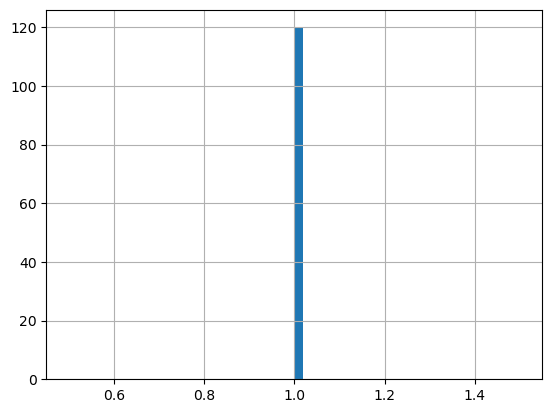

In [11]:
print(vep_df['haplotype_sequence_len_pct'].hist(bins=50))
print(vep_df['haplotype_sequence_len_pct'].describe())


In [12]:
# Plot haplotype_sequence_len_pct vs VEP as point density with regression line
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


# Get the per-protein mean to reduce the size of the dataset
# Downsample to 1000 random rows per protein
# plot_data = vep_df.loc[vep_df['mutant_out_of_frame']==False].sample(100000, random_state=42)
plot_data = vep_df.groupby(['model_location','protein','haplotype','haplotype_sequence_len_pct','clinsig'], observed=True).agg({'VEP': 'mean'}).reset_index()
max_pct = .95
plot_data = plot_data.loc[plot_data['haplotype_sequence_len_pct'] < max_pct]
print(plot_data.shape)
plot_data.head()

# Create a categorical column with the defined order
plot_data['clinsig'] = pd.Categorical(
    plot_data['clinsig'], 
    categories=list(utils.get_clinsig_palette().keys())[::-1], 
    ordered=True
)
# Sort the dataframe by the ordered categorical column
plot_data = plot_data.sort_values('clinsig')

min_vep = plot_data['VEP'].min()
 
# Calculate histogram data for the distribution subplot
hist_data = plot_data.copy()
# Create bins at 5% intervals
bins = np.arange(0, max_pct + 0.05, 0.05)
hist_data['bin'] = pd.cut(hist_data['haplotype_sequence_len_pct'], bins=bins)
# Count unique haplotypes in each bin
haplotype_counts = hist_data.groupby('bin')['haplotype'].nunique().reset_index()
haplotype_counts['bin_center'] = haplotype_counts['bin'].apply(lambda x: x.mid)

# Create new plot with the correct number of rows for the grid
# Get the number of categories to set the correct height_ratios
num_categories = len(plot_data['clinsig'].cat.categories)
g = sns.FacetGrid(plot_data, 
                row='clinsig',  
                sharex=True,
                sharey=True, 
                aspect=1.2,
                height=3)  # Remove the incorrect height_ratios parameter

# Map the custom function to the FacetGrid
g.map_dataframe(sns.kdeplot,
                 x="haplotype_sequence_len_pct",
                 y="VEP", 
                 fill=True, 
                 thresh=0, levels=15, cmap="mako",
                 bw_adjust=1, 
                 clip=[(0, max_pct), (min_vep, None)],  # Ensure x-axis doesn't go below 0
                 extend="both",
                 alpha=1.0
                 )
g.map_dataframe(sns.regplot,
                x="haplotype_sequence_len_pct",
                y="VEP", 
                scatter=False,
                lowess=True,
                n_boot=1000,
                # robust=True,
                ci=95,  # Add confidence interval
                line_kws={"color": "white", "linewidth": 2},
                )

# Calculate and add Pearson correlation for each subplot
for i, clinsig in enumerate(plot_data['clinsig'].cat.categories):
    subset = plot_data[plot_data['clinsig'] == clinsig].dropna(subset=['haplotype_sequence_len_pct', 'VEP'])
    # r, p = stats.spearmanr(subset['haplotype_sequence_len_pct'], subset['VEP'])
    # r2 = r**2 

    import numpy as np
    import statsmodels.api as sm
    from sklearn.metrics import mean_squared_error


    # Sample data (replace with your actual data)
    x_actual = subset['haplotype_sequence_len_pct']
    y_actual = subset['VEP']

    # Fit LOESS model
    lowess = sm.nonparametric.lowess(y_actual, x_actual, frac=0.3)
    x_predicted = lowess[:, 0]
    y_predicted = lowess[:, 1]

    # Calculate SS_res
    residuals = y_actual - y_predicted
    ss_res = np.sum(residuals**2)

    # Calculate SS_tot
    y_mean = np.mean(y_actual)
    ss_tot = np.sum((y_actual - y_mean)**2)

    # Calculate pseudo R-squared
    r2 = 1 - (ss_res / ss_tot)

    # Calculate MSE
    mse = mean_squared_error(y_actual, y_predicted)
    
    ax = g.axes[i, 0]
    ax.text(0.05, 0.95, f'coef = {r2:.3f}, MSE = {mse:.3f}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Set x-axis limits for all subplots to ensure they don't go below 0
g.set(xlim=(0, max_pct))
# Create a separate figure for the histogram with the same width as the facet grid
fig_width, _ = g.fig.get_size_inches()
plt.figure(figsize=(fig_width, 1.5))

# Create the bar plot
bars = plt.bar(haplotype_counts['bin_center'], haplotype_counts['haplotype'], 
        width=0.04, color='darkblue', alpha=0.7)

# Add a line connecting the tops of the bars
bar_heights = haplotype_counts['haplotype']
bar_positions = haplotype_counts['bin_center']
plt.plot(bar_positions, bar_heights, 'b-', alpha=0.5, linewidth=1.1)

# Add dots at the middle of each bar
plt.scatter(bar_positions, bar_heights, color='blue', s=10, zorder=3)

plt.xlim(0, max_pct)  # Use the same x-axis limits as the density plots
plt.xlabel('Haplotype Sequence Length\n(% of Reference)')
plt.ylabel('Unique\nHaplotypes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Set labels and titles
g.set_xlabels('Haplotype Sequence Length\n(% of Reference)')
g.set_ylabels('VEP Score')
g.set_titles('{row_name}')
g.tight_layout()
plt.show()


KeyError: "Column(s) ['VEP'] do not exist"

Filter out variants with less than 50% of the haplotype sequence length.

In [8]:
vep_df = vep_df.loc[vep_df['haplotype_sequence_len_pct']>.5]

### Count number of pathogenic variants already in the haplotype

In [9]:
vep_df = hs.add_haplotype_diffs(vep_df,
                                haplotypes=haplotypes, 
                                force=True)
vep_df.head()

Extracting haplotype diffs:   0%|          | 0/1450 [00:00<?, ?it/s]

95481 diffs from 1450 haplotypes extracted


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,diff_benign,diff_possibly damaging,diff_probably damaging,diff_unknown
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,1509476

plot data shape:  (212314, 7)


KeyboardInterrupt: 

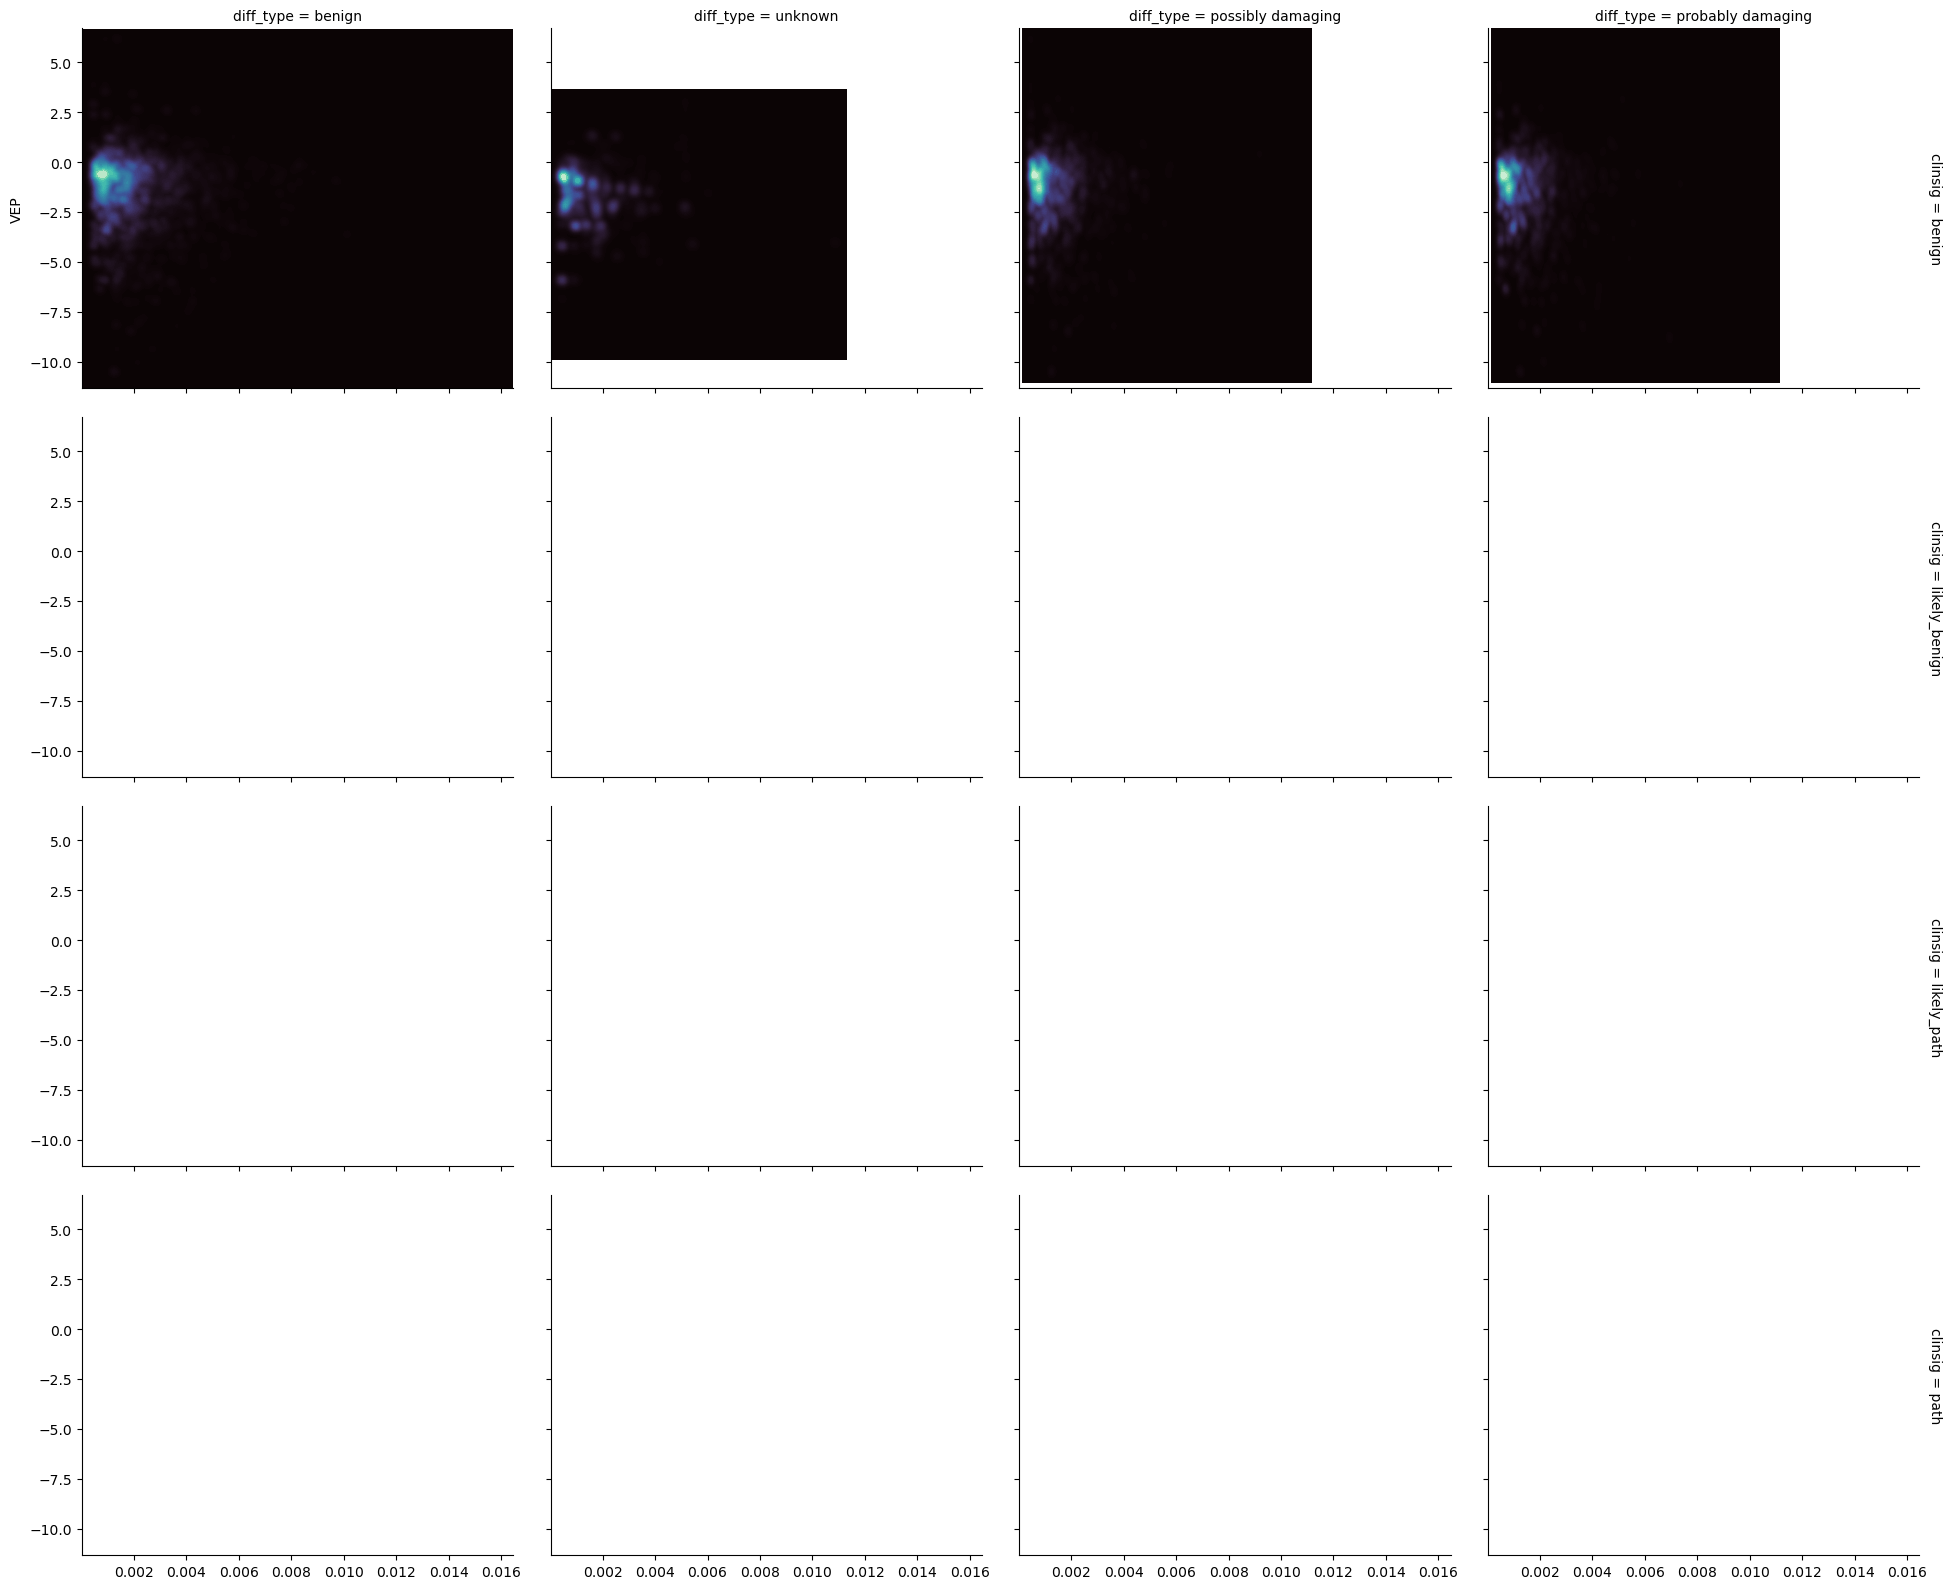

In [13]:
# Melt the diff columns to create a long-format dataframe
diff_cols = [col for col in vep_df.columns if col.startswith('diff_')]
plot_data = vep_df.loc[(vep_df['VEP'].notna()) & (vep_df['mutant_in_haplotype']==False)].melt(
    id_vars=['model_location', 'protein', 'haplotype', 'clinsig', 'VEP','haplotype_sequence_len'],
    value_vars=diff_cols,
    var_name='diff_type',
    value_name='diff_count'
)
plot_data['diff_count_scaled'] = plot_data['diff_count'] / plot_data['haplotype_sequence_len']

plot_data = plot_data.loc[plot_data['diff_count'] > 0]

# Create a categorical column with the defined order
plot_data['clinsig'] = pd.Categorical(
    plot_data['clinsig'], 
    categories=list(utils.get_clinsig_palette().keys())[::-1], 
    ordered=True
)
# Clean up the diff_type column by removing the 'diff_' prefix
plot_data['diff_type'] = plot_data['diff_type'].str.replace('diff_', '')
plot_data['diff_type'] = pd.Categorical(
    plot_data['diff_type'], 
    categories=['benign','unknown', 'possibly damaging', 'probably damaging'], 
    ordered=True
)
# Sort the dataframe by the ordered categorical column
plot_data = plot_data.sort_values(['clinsig','diff_type'])

# # Group by relevant columns and calculate mean VEP score
plot_data = plot_data.groupby(['model_location', 'protein', 'haplotype','clinsig', 'diff_type','diff_count_scaled'], observed=True).agg({'VEP': 'mean'}).reset_index()

# plot_data = plot_data.loc[plot_data['diff_type'] == 'probably damaging']

# plot_data = plot_data.groupby(['clinsig', 'diff_type'], observed=True).sample(1000, random_state=42).reset_index(drop=True)

print("plot data shape: ", plot_data.shape)

g = sns.FacetGrid(data=plot_data, 
                  col='diff_type',
                   row='clinsig',
                   margin_titles=True,
                   height=4, aspect=1.2)
g.map_dataframe(sns.kdeplot, 
                x='diff_count_scaled', 
                y='VEP',
                fill=True,
                thresh=0, levels=50, cmap="mako",
                bw_adjust=0.5, 
                # clip=[(None,max_pct),(min_vep, None)],
                extend="both",
                alpha=1.0
                )
g.map_dataframe(sns.regplot,
                x="diff_count_scaled",
                y="VEP", 
                scatter=False,
                lowess=True,
                line_kws={"color": "white"}
                )
g.add_legend()

In [ ]:
# # Remove any existing hap_mutations columns if they exist
# force = True
# if any([col for col in vep_df.columns if col.startswith('n_')]) and force:
#     vep_df = vep_df.drop(columns=[col for col in vep_df.columns if col.startswith('n_')])

# # Pivot the table to create columns for each clinsig category
# hap_mutations = vep_df.loc[vep_df['mutant_in_haplotype']==True].pivot_table(
#     index='haplotype',
#     columns='clinsig',
#     values='mutant',
#     aggfunc='nunique',
#     fill_value=0
# ).add_prefix('nWT_')

# # Convert all columns to integer type
# hap_mutations = hap_mutations.astype(int)
# hap_mutations
# #merge back into vep_df
# vep_df = vep_df.merge(hap_mutations, left_on='haplotype', right_index=True, how='left')
# vep_df[hap_mutations.columns] = vep_df[hap_mutations.columns].fillna(0)
# vep_df.head()
# # Plot haplotype_sequence_len_pct vs VEP as point density with regression line

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,reference_sequence_len,haplotype_sequence,haplotype_sequence_len,mutant_out_of_frame,haplotype_sequence_len_pct,nWT_benign,nWT_likely_benign,nWT_likely_path,nWT_path
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,1159,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159.0,False,1.0,0.0,0.0,0.0,0.0
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,1159,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159.0,False,1.0,0.0,0.0,0.0,0.0
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,1159,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159.0,False,1.0,0.0,0.0,0.0,0.0
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PA

In [10]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [11]:
# seq_check_df, clinsig_counts, mutant_in_haplotype = va.report_vep(vep_df)
# display(seq_check_df, clinsig_counts, mutant_in_haplotype)

## Plots: All Proteins

Filter out variants with less than 50% of the haplotype sequence length.

In [ ]:
vep_df = vep_df.loc[vep_df['haplotype_sequence_len_pct']>.5]

### Density plots

Filtered 0.6% of rows with NAs in col 'VEP'


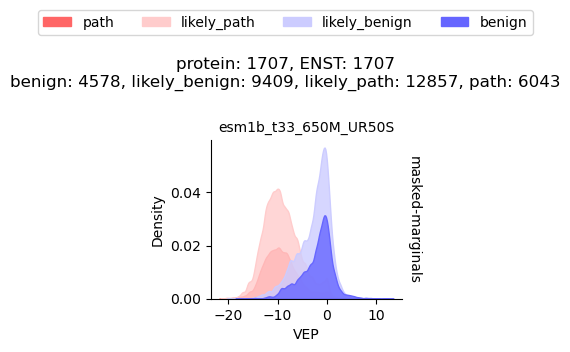

In [17]:
va.plot_vep_density(vep_df, 
                     multiple=['layer','stack','fill'][0],
                     row='scoring_strategy',
                     col='model_location',    
                     legend_y=1.1,
                     aspect=1,
                     save_path="results/plots/vep_density.png"
                     )

### Variance plots

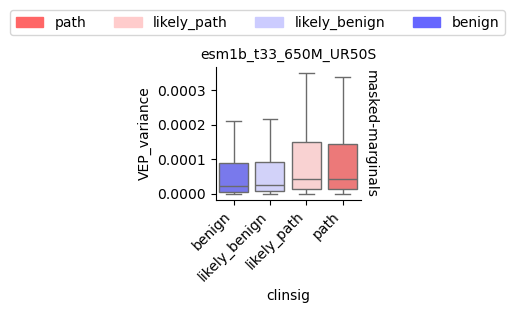

In [19]:
vep_variance = va.plot_vep_variance(vep_df, 
                                    return_df=True,
                                    showfliers=False,
                                    col='model_location',
                                    row='scoring_strategy',
                                    # save_path="results/plots/vep_variance.png",
                                    groupby_cols = ['model_location','protein',
                                                    'clinsig','mutant','scoring_strategy'],
                                    height=3
                                    )

## Plots: Single Protein

### Violin plots: wt-marginals

In [98]:
va.plot_vep_violin(vep_df, 
                #    model_location="esm2_t33_650M_UR50D",
                   max_proteins=1,
                   max_models=1,
                   save_path="results/plots/vep_violin;esm2_t33_650M_UR50D;wt-marginals.png",
                   scoring_strategy="wt-marginals")

Filtered 0.5% of rows with NAs in col 'VEP'


ValueError: Number of rows must be a positive integer, not 0

<Figure size 600x0 with 0 Axes>

### Violin plots: masked-marginals

Filtered 0.1% of rows with NAs in col 'VEP'


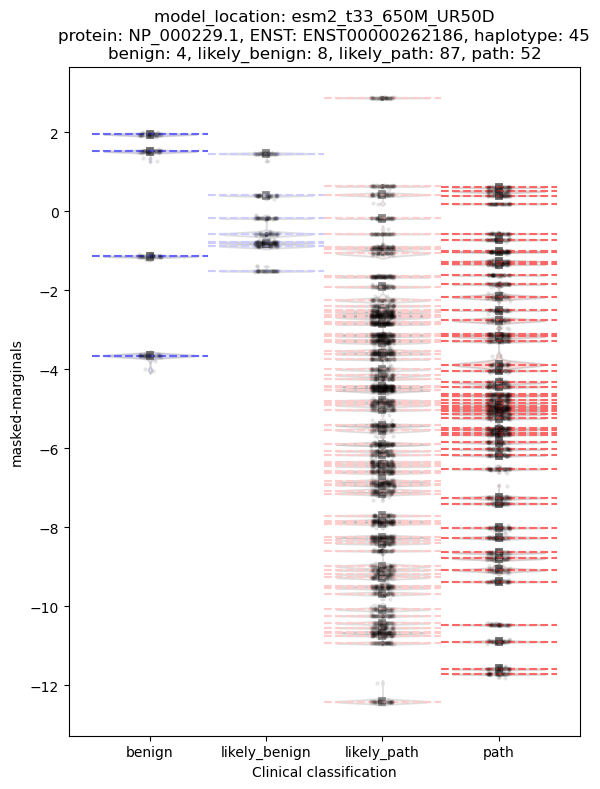

In [61]:
va.plot_vep_violin(vep_df, 
                   model_location="esm2_t33_650M_UR50D",
                    max_proteins=1,
                    max_models=1,
                    save_path="results/plots/vep_violin;esm2_t33_650M_UR50D;masked-marginals.png",
                    scoring_strategy="masked-marginals")

### Haplotype Representiveness

In [62]:
vep_df['VEP_percentile'] = vep_df.groupby(['model_location', 'protein', 'mutant','scoring_strategy'])['VEP'].rank(pct=True)
vep_df[['VEP_percentile']]

,VEP_percentile
0,0.955556
1,0.066667
2,0.066667
3,0.977778
4,0.866667
...,...
2028072,0.973214
2028073,0.964286
2028074,0.776786
2028075,1.000000


### Reference Representativeness: Percentiles

In [49]:
vep_df = hs.add_haplotype_freqs(df=vep_df)
vep_df.head()

Adding 'ENST' column
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 3.18GB/s]


Getting haplotypes:   0%|          | 0/1450 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1450 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    14374
1000GENOMES:phase_3:EAS     9624
1000GENOMES:phase_3:SAS     8993
1000GENOMES:phase_3:EUR     6757
1000GENOMES:phase_3:AMR     4774
Name: count, dtype: int64

Percentage of population-specific haplotypes: 76.60%


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,1000GENOMES:phase_3:ASW,_all,1000GENOMES:phase_3:EAS,1000GENOMES:phase_3:PEL,1000GENOMES:phase_3:LWK,1000GENOMES:phase_3:KHV,GGVP:GWJ,1000GENOMES:phase_3:CHS,1000GENOMES:phase_3:CEU,GGVP:GWF,1000GENOMES:phase_3:MSL,1000GENOMES:phase_3:BEB,1000GENOMES:phase_3:ESN,1000GENOMES:phase_3:CHB,1000GENOMES:phase_3:IBS,GGVP:GWD,1000GENOMES:phase_3:PUR,1000GENOMES:phase_3:ITU,GGVP:GWW,1000GENOMES:phase_3:CLM,1000GENOMES:phase_3:GWD,1000GENOMES:phase_3:GBR,1000GENOMES:phase_3:CDX,1000GENOMES:phase_3:STU,1000GENOMES:phase_3:GIH,1000GENOMES:phase_3:TSI,1000GENOMES:phase_3:SAS,1000GENOMES:phase_3:EUR,1000GENOMES:phase_3:PJL,1000GENOMES:phase_3:AMR,1000GENOMES:phase_3:FIN,1000GENOMES:phase_3:ACB,1000GENOMES:phase_3:AFR,1000GENOMES:phase_3:MXL,1000GENOMES:phase_3:YRI,1000GENOMES:phase_3:ALL,1000GENOMES:phase_3:JPT,GGVP:ALL,freq_all_x,freq_GGVP:GWJ_x,freq_GGVP:GWF_x,freq_GGVP:GWD_x,freq_GGVP:GWW_x,freq_GGVP:ALL_x,freq_1000GENOMES:phase_3:ASW,freq_all_y,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:LWK,freq_1000GENOMES:phase_3:KHV,freq_GGVP:GWJ_y,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CEU,freq_GGVP:GWF_y,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:IBS,freq_GGVP:GWD_y,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:ITU,freq_GGVP:GWW_y,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:YRI,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:JPT,freq_GGVP:ALL_y,top_pop,top_superpop,top_superpop_freq,nonzero_superpop_freqs,specific_superpopulation
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,NaN,0.000166,0.000992,NaN,NaN,0.005051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0002,NaN,NaN,0.000166,NaN,NaN,NaN,NaN,NaN,NaN,0.000166,0.000992,NaN,NaN,0.005051,NaN,NaN,NaN,NaN,NaN

<string>:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


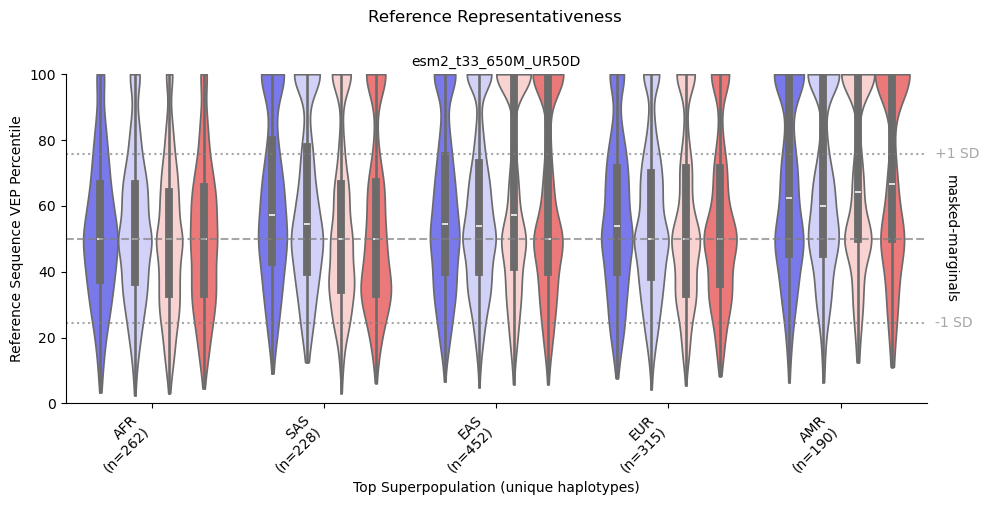

In [69]:
vep_df['Top Superpopulation'] = vep_df['top_superpop'].str.split(':').str[-1]
va.plot_vep_percentiles(vep_df.loc[vep_df['haplotype_sequence_len_pct'] > .5], 
                        col='model_location',
                        x="Top Superpopulation",
                        row='scoring_strategy',
                         groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy',
                                         "Top Superpopulation"],
                        height=5,
                        aspect=2,
                        save_path="results/plots/vep_percentiles.png")

In [64]:
vep_df.loc[vep_df['is_ref']==True]['VEP_percentile'].describe()

count    36074.000000
mean         0.460724
std          0.180227
min          0.008475
25%          0.333333
50%          0.450000
75%          0.562500
max          1.000000
Name: VEP_percentile, dtype: float64

Get genes where the reference is the LEAST representitive

In [65]:
vep_df.loc[:,'VEP_percentile_deivation'] = abs(vep_df['VEP_percentile'] - 50)
most_deviant_ref = vep_df.loc[vep_df['is_ref']==True].groupby(['model_location', 'scoring_strategy','protein']).agg({'VEP_percentile_deivation':['count','min','max','mean','median']}).sort_values(('VEP_percentile_deivation','mean'), ascending=False).reset_index()
most_deviant_ref.head(10)

model_location  scoring_strategy         protein  \
                                                           
0  esm2_t33_650M_UR50D  masked-marginals  NP_001171582.1   
1  esm2_t33_650M_UR50D  masked-marginals     NP_057049.5   
2  esm2_t33_650M_UR50D  masked-marginals     NP_056348.2   
3  esm2_t33_650M_UR50D  masked-marginals     NP_003005.2   
4  esm2_t33_650M_UR50D  masked-marginals     NP_116281.2   
5  esm2_t33_650M_UR50D  masked-marginals     NP_002791.1   
6  esm2_t33_650M_UR50D  masked-marginals     NP_036361.1   
7  esm2_t33_650M_UR50D  masked-marginals     NP_005678.3   
8  esm2_t33_650M_UR50D  masked-marginals  NP_001278933.1   
9  esm2_t33_650M_UR50D  masked-marginals     NP_000683.3   

  VEP_percentile_deivation                                              
                     count        min        max       mean     median  
0                        2  49.833333  49.833333  49.833333  49.833333  
1                        2  49.800000  49.800000  49.800000  49.800000  
2                        3  49.663934  49.864407  49.791056  49.844828  
3                        5  49.692308  49.846154  49.784615  49.807692  
4                        2  49.750000  49.812500  49.781250  49.781250  
5                        3  49.642857  49.892857  49.773810  49.785714  
6                        4  49.656250  49.906250  49.773438  49.765625  
7                       11  49.406250  49.937500  49.767045  49.843750  
8                       23  49.538462  49.923077  49.765886  49.769231  
9                        6  49.518182  49.909091  49.761841  49.790909

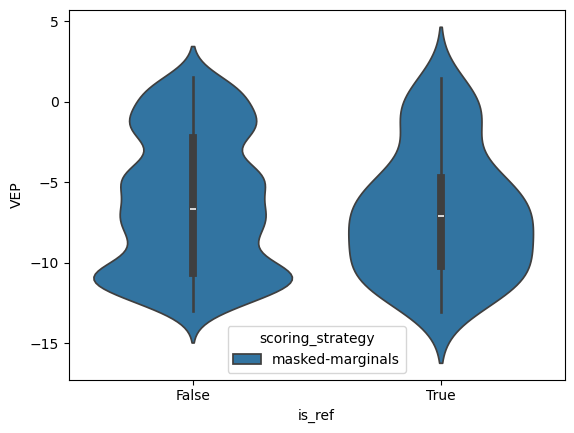

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a FacetGrid to facet by scoring_strategy
g = sns.violinplot(data=vep_df.loc[vep_df['protein'].isin(most_deviant_ref['protein'].unique()[:12])],
                   x='is_ref',
                   y='VEP',
                   hue='scoring_strategy',
                   )
plt.show()

In [67]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
gp_df = gp.profile(organism='hsapiens',
           background=vep_files['protein'].unique().tolist(),
           query=most_deviant_ref['protein'].unique().tolist()[:50]
           )
gp_df


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents


## Precision-Recall 

### Add edit distance metrics

In [94]:
# Add the number of edits (variants relative to the reference) per haplotype
vep_df = utils.add_edits(vep_df)

# Scale edits by protein sequence length
seq_lens = {seq:len(seq) for seq in vep_df['protein_sequence']}
vep_df['protein_sequence_len'] = vep_df['protein_sequence'].map(seq_lens)
vep_df['edits_scaled'] = vep_df['edits'] / vep_df['protein_sequence_len']
vep_df['edits_clipped'] = vep_df['edits'].clip(upper=20)
vep_df.loc[:,'edits_scaled_rounded'] = vep_df['edits_scaled'].round(3)

# vep_df['edits_scaled_quartiles'] = pd.qcut(vep_df.groupby(['protein','mutant'])['edits_scaled'], q=10, labels=False)
# vep_df['edits_scaled_quartiles'].value_counts()

Filter to only include variants with high-confidence annotations.

In [95]:
print(vep_df.groupby("clinsig")['CLNREVSTAT'].value_counts())

vep_qc = vep_df.loc[(vep_df['clinsig'].isin(["path","benign"])) &\
                    (vep_df['CLNREVSTAT'].isin(['reviewed_by_expert_panel','practice_guideline']))]

clinsig        CLNREVSTAT                                          
benign         criteria_provided,_single_submitter                     333452
               criteria_provided,_multiple_submitters,_no_conflicts    259188
               reviewed_by_expert_panel                                 67894
likely_benign  criteria_provided,_single_submitter                     927813
               criteria_provided,_multiple_submitters,_no_conflicts    513666
               reviewed_by_expert_panel                                 13291
likely_path    criteria_provided,_single_submitter                     723754
               criteria_provided,_multiple_submitters,_no_conflicts    437389
               reviewed_by_expert_panel                                 43397
path           criteria_provided,_single_submitter                     307734
               criteria_provided,_multiple_submitters,_no_conflicts    132227
               reviewed_by_expert_panel                                 97

In [96]:
vep_pr = va.compute_precision_recall(vep_qc,
                                     groupby_cols = ['model_location', 'scoring_strategy',
                                                     'protein',
                                                     'is_ref', 
                                                     'protein_sequence_len', 'haplotype',
                                                    #  'edits',
                                                    'edits_scaled_rounded'
                                                     ],
                                     agg_cols = ['protein','protein_sequence_len', 'haplotype'],
                                     x='VEP',
                                     y='DMS_bin_score')


Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/3639 [00:00<?, ?it/s]

In [99]:
print(vep_pr.shape)
vep_pr.head()

(43, 9)


,scoring_strategy,model_location,is_ref,edits_scaled_rounded,accuracy,auc,coef,intercept,n_samples
0,masked-marginals,esm1_t34_670M_UR50D,False,0.001,0.869699,0.862301,-0.418116,-2.301909,17097
1,masked-marginals,esm1_t34_670M_UR50D,False,0.002,0.951569,0.952633,-0.675808,-3.290716,4298
2,masked-marginals,esm1_t34_670M_UR50D,False,0.003,0.925488,0.828541,-0.700510,-3.176116,7567
3,masked-marginals,esm1_t34_670M_UR50D,False,0.004,1.000000,1.000000,-0.335300,-1.973312,104
4,masked-marginals,esm1_t34_670M_UR50D,False,0.005,0.966387,1.000000,-0.986889,-5.020192,328


In [101]:
vep_pr_ref_only = va.compute_precision_recall(vep_qc.loc[vep_qc['is_ref']==True],
                                     groupby_cols = ['model_location', 'scoring_strategy','protein'],
                                     agg_cols = ['protein'],
                                     x='VEP',
                                     y='DMS_bin_score')
vep_pr_ref_only['group'] = 'Ref only'
vep_pr_all = va.compute_precision_recall(vep_qc,
                                     groupby_cols = ['model_location', 'scoring_strategy','protein'],
                                     agg_cols = ['protein'],
                                     x='VEP',
                                     y='DMS_bin_score')
vep_pr_all['group'] = 'All'
vep_pr_grouped = pd.concat([vep_pr_ref_only, vep_pr_all])
vep_pr_grouped


Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/67 [00:00<?, ?it/s]

Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/69 [00:00<?, ?it/s]

,model_location,scoring_strategy,accuracy,auc,coef,intercept,n_samples,group
0,esm1_t34_670M_UR50D,masked-marginals,0.922827,0.923887,-0.626985,-2.935390,492,Ref only
1,esm1_t6_43M_UR50S,masked-marginals,0.867102,0.750367,-0.562018,-1.214258,196,Ref only
2,esm1b_t33_650M_UR50S,masked-marginals,0.941176,0.951724,-1.035698,-6.061322,34,Ref only
3,esm1v_t33_650M_UR90S_1,masked-marginals,0.970588,0.944828,-0.889119,-3.404146,34,Ref only
4,esm2_t12_35M_UR50D,masked-marginals,0.810120,0.787691,-0.339665,-0.364349,586,Ref only
5,esm2_t33_650M_UR50D,masked-marginals,0.937364,0.933678,-0.729286,-3.091472,196,Ref only
0,esm1_t34_670M_UR50D,masked-marginals,0.932224,0.923185,-0.998520,-6.114943,30296,All
1,esm1_t6_43M_UR50S,masked-marginals,0.867074,0.750241,-0.598848,-1.305849,19366,All
2,esm1b_t33_650M_UR50S,masked-marginals,0.940107,0.949987,-1.409723,-8.620766,1870,All
3,esm1v_t33_650M_UR90S_1,masked-marginals,0.970588,0.945562,-1.064717,-4.330592,1870,All


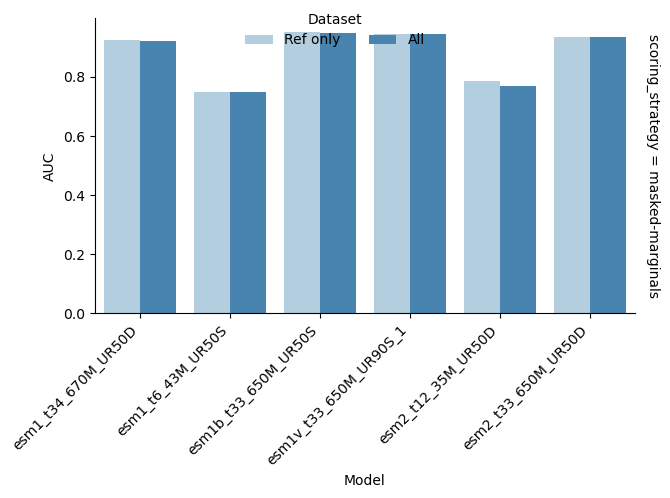

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a FacetGrid to facet by scoring_strategy
g = sns.FacetGrid(data=vep_pr_grouped,
                  row="scoring_strategy",
                  margin_titles=True,
                  height=5, 
                  aspect=1)

# Map the barplot to each facet
g.map_dataframe(sns.barplot, 
                x="model_location", 
                y="auc", 
                hue="group",
                palette='Blues')

# Fix x-axis labels - apply rotation to each subplot
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Adjust layout and add titles
g.set_axis_labels("Model", "AUC")
# _rm_subplot_prefixes(g)

# Add a legend for the hue variable
g.add_legend(title="Dataset", loc='upper center', ncol=2)

plt.tight_layout()
plt.show()

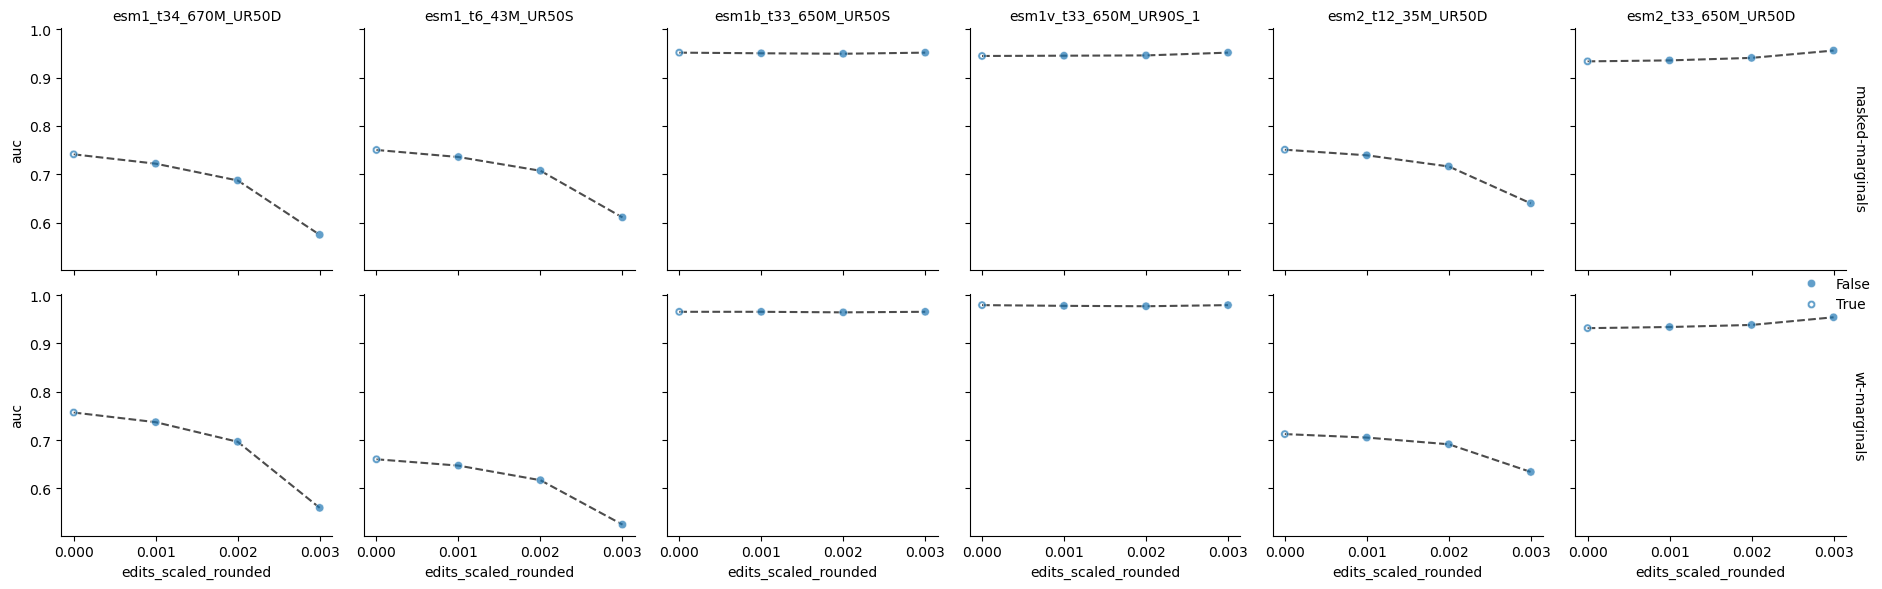

In [26]:
va.plot_auc_by_edits(vep_pr, #vep_pr.loc[vep_pr['edits'] < 20],
                      col="model_location",
                      row="scoring_strategy", 
                      style="is_ref",
                     x="edits_scaled_rounded", 
                     save_path="results/plots/vep_pr_auc_by_edits.png")

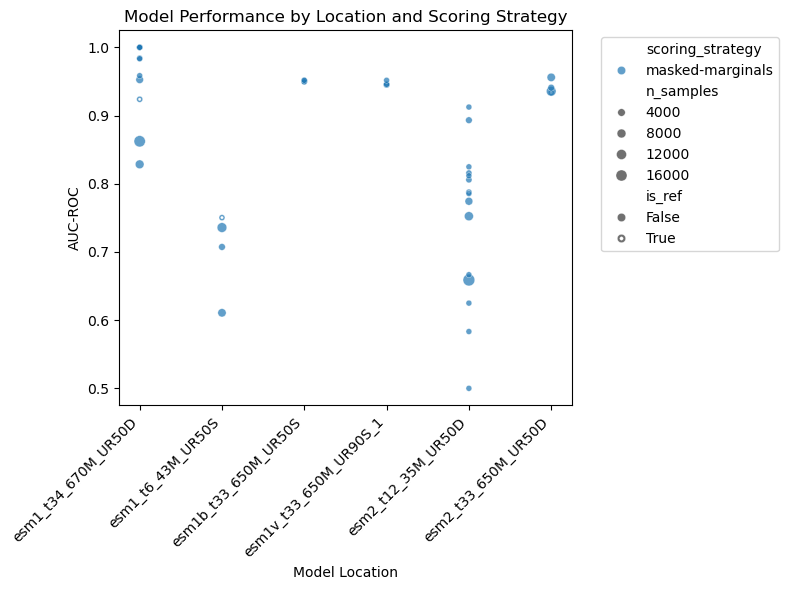

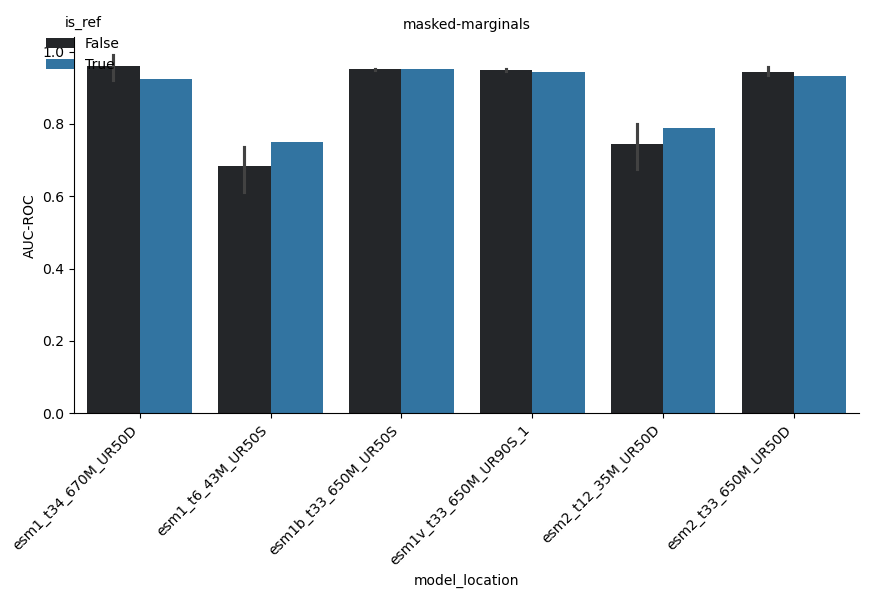

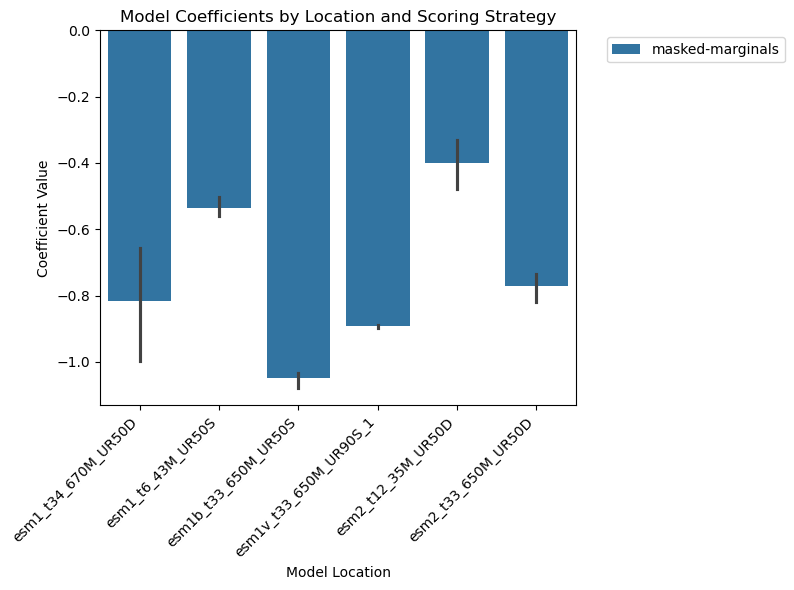

In [103]:
va.plot_precision_recall(vep_pr,
                         style='is_ref',
                         
                         save_path="results/plots/precision_recall.png",
                         hue='scoring_strategy')

### Pairwise correlations between haplotypes
Compute pairwise correlations between all haplotypes for a given protein.

In [105]:
# Group by protein and pivot to get haplotype columns
tqdm.pandas(desc="Pivoting VEP")
vep_pivot = vep_df.groupby('protein').progress_apply(lambda x: pd.pivot_table(x,
                                                                    index=['protein', 'mutant'],
                                                                    columns='edits_clipped',
                                                                    values='VEP',
                                                                    # Only include haplotypes for this protein
                                                                    dropna=True))
vep_pivot


Pivoting VEP:   0%|          | 0/1772 [00:00<?, ?it/s]

edits_clipped                          0          1          2         20  3   \
protein     protein     mutant                                                  
NP_000007.1 NP_000007.1 A113D   -7.708576  -7.715696  -7.693262 -7.758820 NaN   
                        A113T   -4.232880  -4.237339  -4.239253 -4.131114 NaN   
                        A136V   -2.095088  -2.079986  -2.093937 -2.206535 NaN   
                        A165T   -2.368854  -2.382868  -2.369235 -2.368831 NaN   
                        A205P   -5.687437  -5.676813  -5.668174 -5.591449 NaN   
...                                   ...        ...        ...       ...  ..   
NP_998885.1 NP_998885.1 R15L    -9.027851  -8.889543  -9.132408       NaN NaN   
                        S59L   -19.177984 -19.245420 -18.696195       NaN NaN   
                        S77G    -1.477943  -1.495848  -1.485637       NaN NaN   
                        T90P     3.208157   3.182882   2.964261       NaN NaN   
                        Y135H    2.782606   2.666708   2.839180       NaN NaN   

edits_clipped                   4   5   6   7   8   10  11  19  18  14  17  \
protein     protein     mutant                                               
NP_000007.1 NP_000007.1 A113D  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A113T  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A136V  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A165T  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A205P  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                             ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NP_998885.1 NP_998885.1 R15L   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        S59L   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        S77G   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        T90P   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        Y135H  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

edits_clipped                   12  9   16  13  15  
protein     protein     mutant                      
NP_000007.1 NP_000007.1 A113D  NaN NaN NaN NaN NaN  
                        A113T  NaN NaN NaN NaN NaN  
                        A136V  NaN NaN NaN NaN NaN  
                        A165T  NaN NaN NaN NaN NaN  
                        A205P  NaN NaN NaN NaN NaN  
...                             ..  ..  ..  ..  ..  
NP_998885.1 NP_998885.1 R15L   NaN NaN NaN NaN NaN  
                        S59L   NaN NaN NaN NaN NaN  
                        S77G   NaN NaN NaN NaN NaN  
                        T90P   NaN NaN NaN NaN NaN  
                        Y135H  NaN NaN NaN NaN NaN  

[45278 rows x 21 columns]

In [106]:
vep_pivot.index.get_level_values('mutant').value_counts()

# Calculate percentage of non-NA values for each row
pct_nonna = (vep_pivot.notna().sum(axis=0) / vep_pivot.shape[0] * 100).round(2)

pct_nonna.describe()


count     21.000000
mean      17.549524
std       32.147812
min        0.020000
25%        0.080000
50%        0.530000
75%       17.370000
max      100.000000
dtype: float64

In [107]:
vep_pivot.index.get_level_values(0).nunique()

1772

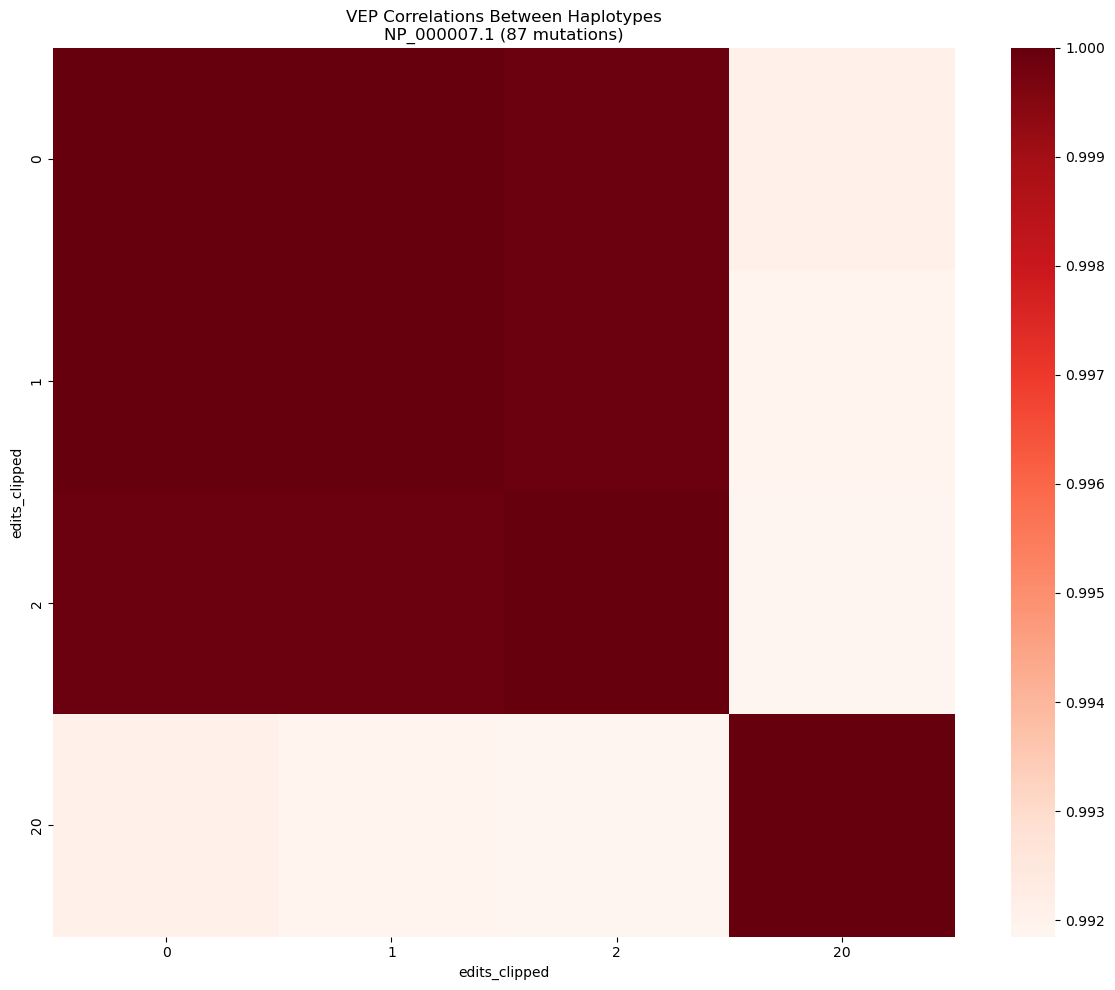

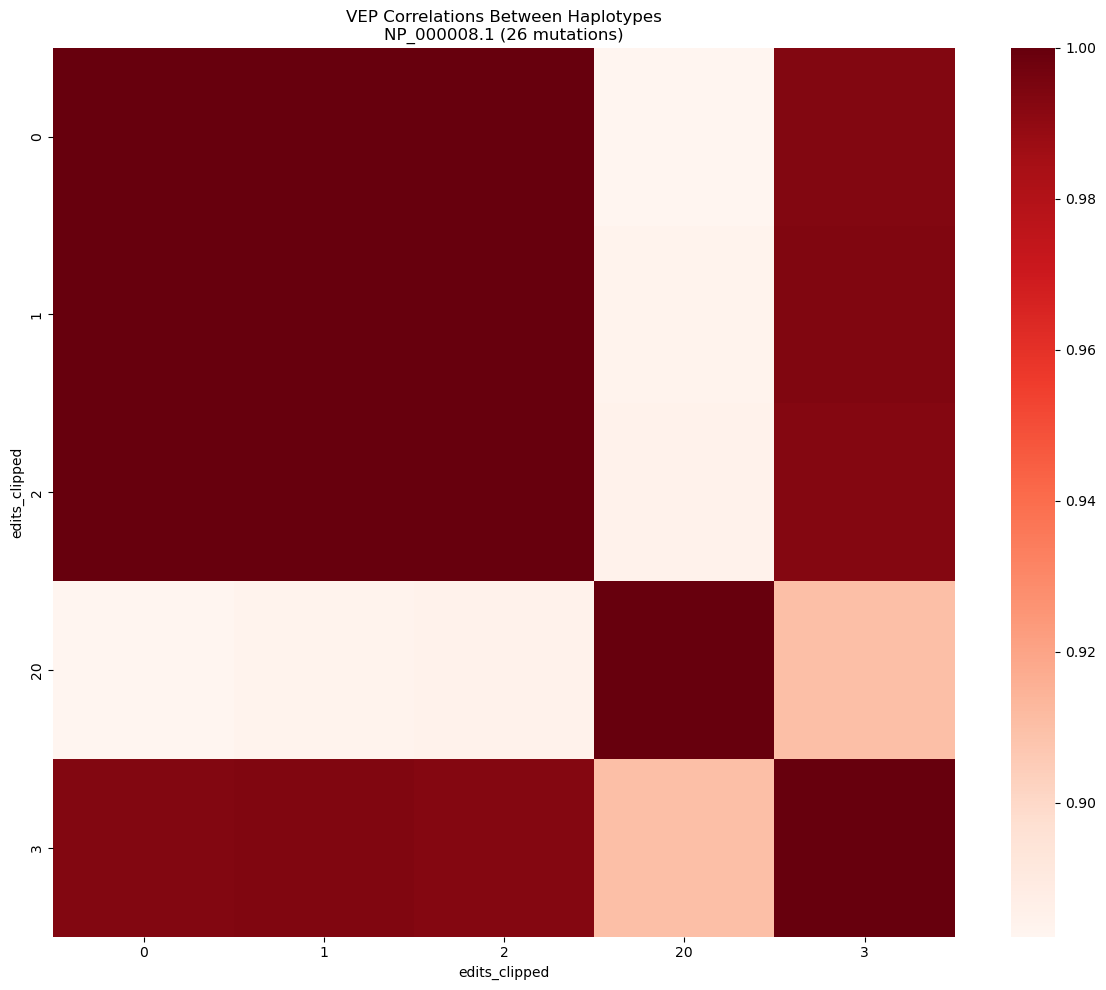

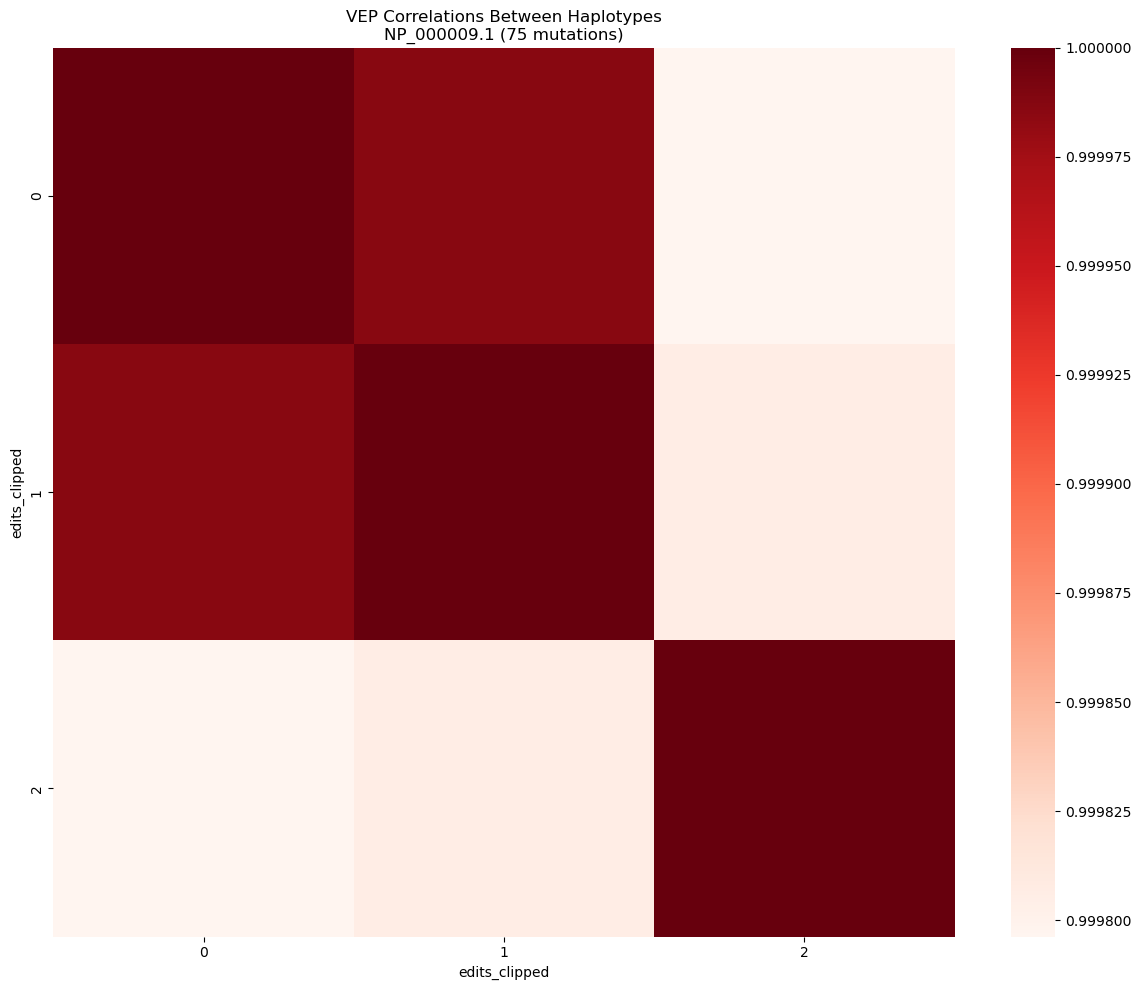

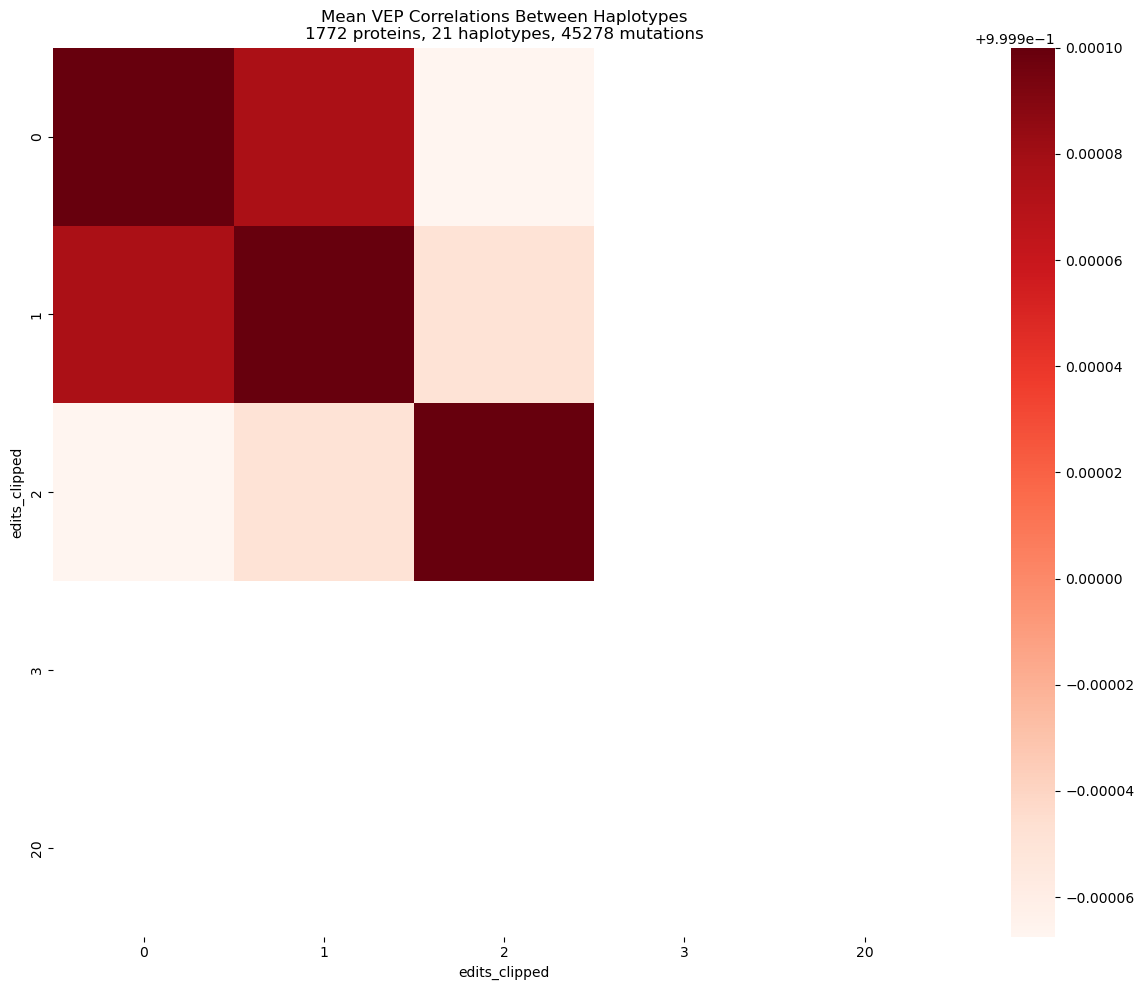

In [109]:
# Compute correlations within each protein
vep_corr = vep_pivot.groupby('protein').apply(lambda x: x.corr())
import matplotlib.pyplot as plt
import seaborn as sns
# Create list to store correlation matrices
corr_matrices = []

max_proteins = 3
# Get correlation matrix for each protein
for protein in vep_corr.index.get_level_values(0).unique()[:max_proteins]:
    corr_matrix = vep_corr.loc[protein]
    # Remove columns that are all NA
    corr_matrix = corr_matrix.dropna(axis=1, how='all')
    # Remove rows that are all NA 
    corr_matrix = corr_matrix.dropna(axis=0, how='all')
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_matrix,
                cmap='Reds', 
                # center=vep_corr.mean().mean(),
                # vmin=vep_corr.min().min(),
                # vmax=vep_corr.max().max()
                )
    n_mutations = len(vep_pivot.loc[protein].index)
    plt.title(f'VEP Correlations Between Haplotypes\n{protein} ({n_mutations} mutations)')
    plt.tight_layout()
    plt.show()
    corr_matrices.append(corr_matrix)

# Calculate mean correlation matrix
mean_corr = sum(corr_matrices) / len(corr_matrices)

# Plot mean correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(mean_corr,
            cmap='Reds',
            )
plt.title(f'Mean VEP Correlations Between Haplotypes\n{vep_pivot.index.get_level_values(0).nunique()} proteins, {len(vep_pivot.columns)} haplotypes, {len(vep_pivot.index)} mutations')
plt.tight_layout()
plt.show()


## Define decision boundaries between benign and pathogenic variants

### Identify cases where the VEP of pathogenic variants overlaps with the VEP of benign variants 

Within the same model_location, metric, protein


100%|██████████| 1450/1450 [00:03<00:00, 458.50it/s]

Total protein-model-scoring combinations: 1450
Combinations with VEP overlap between pathogenic and benign variants: 910
Percentage of combinations with overlap: 62.76%

Proteins with VEP overlap between pathogenic and benign variants:


,protein,model_location,scoring_strategy,benign_count,path_count,benign_min,benign_max,path_min,path_max,has_overlap,overlap_range
89,NP_000248.2,esm2_t33_650M_UR50D,masked-marginals,850,14200,-12.744274,1.448570,-16.255283,2.491493,True,14.192844
533,NP_002464.1,esm2_t33_650M_UR50D,masked-marginals,3456,3360,-13.407917,2.211023,-13.772314,0.606530,True,14.014447
475,NP_001839.2,esm2_t33_650M_UR50D,masked-marginals,11880,5808,-11.589870,6.066015,-14.854788,1.890579,True,13.480450
168,NP_000486.1,esm2_t33_650M_UR50D,masked-marginals,6192,18192,-11.925434,4.662473,-15.337345,1.113979,True,13.039413
883,NP_009225.1,esm2_t33_650M_UR50D,masked-marginals,33136,16568,-11.576826,1.649102,-14.820344,1.276781,True,12.853607
...,...,...,...,...,...,...,...,...,...,...,...
598,NP_003482.1,esm2_t33_650M_UR50D,masked-marginals,1,21,-8.067976,-8.067976,-12.242023,-7.050572,True,0.000000
426,NP_001354906.1,esm2_t33_650M_UR50D,masked-marginals,89,89,0.000000,0.519949,-11.300444,0.000000,True,0.000000
1260,NP_115979.3,esm2_t33_650M_UR50D,masked-marginals,2,1,-1.279504,2.386183,-0.800049,-0.800049,True,0.000000
400,NP_001273644.1,esm2_t33_650M_UR50D,masked-marginals,56,112,0.000000,0.395210,-11.109603,0.000000,True,0.000000


/tmp/ipykernel_1713748/307359086.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Clinical Significance")


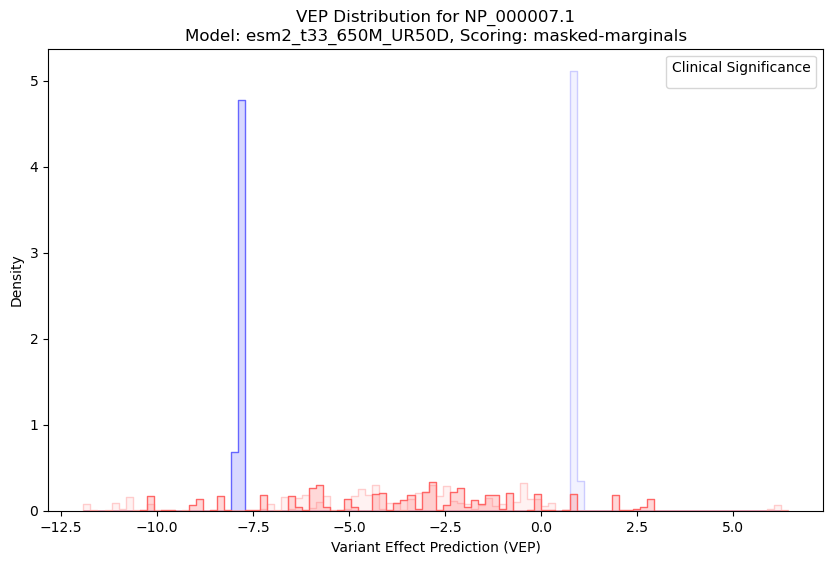

In [ ]:
# Group by protein, model_location, and scoring_strategy
# For each group, check if there's overlap between pathogenic and benign VEP distributions
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
overlap_results = []
groupby_cols = ['protein', 'model_location', 'scoring_strategy']

for (protein, model, scoring), group in tqdm(vep_df.groupby(groupby_cols), 
                                             total=len(vep_df.groupby(groupby_cols))):
    # Get benign and pathogenic variants
    benign_variants = group[group['clinsig'].isin(['benign', 'likely_benign'])]
    path_variants = group[group['clinsig'].isin(['path', 'likely_path'])]
    
    # Only proceed if we have both types of variants
    if len(benign_variants) > 0 and len(path_variants) > 0:
        # Get min and max VEP for each category
        benign_min = benign_variants['VEP'].min()
        benign_max = benign_variants['VEP'].max()
        path_min = path_variants['VEP'].min()
        path_max = path_variants['VEP'].max()
        
        # Check for overlap
        has_overlap = (path_min <= benign_max) and (benign_min <= path_max)
        
        # Calculate overlap range if there is overlap
        overlap_range = None
        if has_overlap:
            overlap_min = max(benign_min, path_min)
            overlap_max = min(benign_max, path_max)
            overlap_range = overlap_max - overlap_min
        
        # Store results
        overlap_results.append({
            'protein': protein,
            'model_location': model,
            'scoring_strategy': scoring,
            'benign_count': len(benign_variants),
            'path_count': len(path_variants),
            'benign_min': benign_min,
            'benign_max': benign_max,
            'path_min': path_min,
            'path_max': path_max,
            'has_overlap': has_overlap,
            'overlap_range': overlap_range
        })

# Convert to DataFrame
overlap_df = pd.DataFrame(overlap_results)

# Display summary
print(f"Total protein-model-scoring combinations: {len(overlap_df)}")
print(f"Combinations with VEP overlap between pathogenic and benign variants: {overlap_df['has_overlap'].sum()}")
print(f"Percentage of combinations with overlap: {100 * overlap_df['has_overlap'].mean():.2f}%")

# Display proteins with overlap
if len(overlap_df[overlap_df['has_overlap']]) > 0:
    print("\nProteins with VEP overlap between pathogenic and benign variants:")
    display(overlap_df[overlap_df['has_overlap']].sort_values('overlap_range', ascending=False))

# Visualize one example of overlap if any exists
if overlap_df['has_overlap'].any():
    # Get the protein with the largest overlap
    example_protein = overlap_df.loc[overlap_df['has_overlap'], 'protein'].iloc[0]
    example_model = overlap_df.loc[overlap_df['has_overlap'], 'model_location'].iloc[0]
    example_scoring = overlap_df.loc[overlap_df['has_overlap'], 'scoring_strategy'].iloc[0]
    
    # Filter data for this protein
    example_data = vep_df[(vep_df['protein'] == example_protein) & 
                          (vep_df['model_location'] == example_model) &
                          (vep_df['scoring_strategy'] == example_scoring)]
    
    # Create plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data=example_data, x='VEP', hue='clinsig', 
                 palette=utils.get_clinsig_palette(), 
                 bins=100,
                 element='step', common_norm=False, stat='density')
    plt.title(f"VEP Distribution for {example_protein}\nModel: {example_model}, Scoring: {example_scoring}")
    plt.xlabel("Variant Effect Prediction (VEP)")
    plt.ylabel("Density")
    plt.legend(title="Clinical Significance")
    plt.show()


Training GMMs: 100%|██████████| 1450/1450 [01:06<00:00, 21.92it/s]


Total model-protein-scoring combinations with GMM models: 1445
Average accuracy: 0.2143
Average AUC: 0.8812

Top 10 models by accuracy:
                    model         protein  scoring_strategy  accuracy  \
565   esm2_t33_650M_UR50D     NP_002959.2  masked-marginals  0.942134   
1422  esm2_t33_650M_UR50D     NP_938011.1  masked-marginals  0.929825   
1043  esm2_t33_650M_UR50D     NP_058633.2  masked-marginals  0.888889   
251   esm2_t33_650M_UR50D  NP_001025054.1  masked-marginals  0.876725   
814   esm2_t33_650M_UR50D     NP_006197.1  masked-marginals  0.876302   
589   esm2_t33_650M_UR50D     NP_003325.2  masked-marginals  0.870968   
946   esm2_t33_650M_UR50D     NP_055496.2  masked-marginals  0.867647   
986   esm2_t33_650M_UR50D     NP_056240.2  masked-marginals  0.863636   
1351  esm2_t33_650M_UR50D     NP_689854.2  masked-marginals  0.857143   
1249  esm2_t33_650M_UR50D     NP_115763.2  masked-marginals  0.847826   

      precision  recall   f1       auc  benign_count  path_c

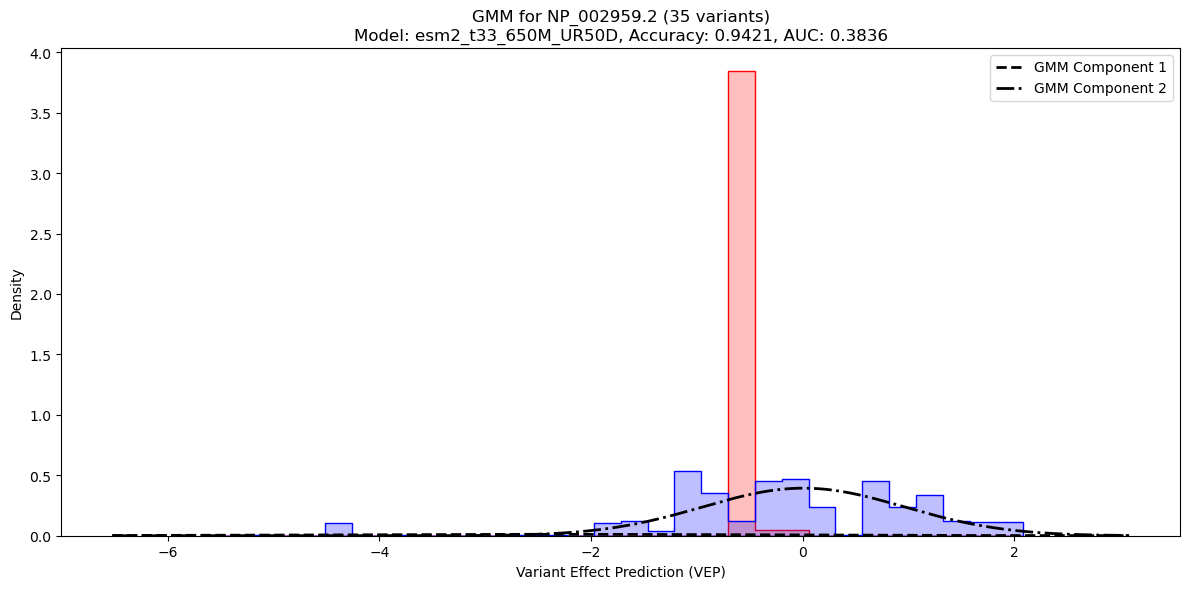

In [10]:
import src.vep_gmm as vg

gmm_df = vg.train_vep_gmm(vep_df)

In [11]:
boundary_crossing_df = vg.get_decision_boundaries(gmm_df, vep_df, plot=False)
boundary_crossing_df.head()

Finding boundary-crossing variants: 100%|██████████| 36074/36074 [00:21<00:00, 1708.96it/s] 


No variants found that cross decision boundaries in different haplotypes


,protein,mutant,clinsig,decision_boundary,min_vep,max_vep,vep_range,haplotype_count,scores_above_boundary,scores_below_boundary,crossing_proportion
0,NP_000007.1,M326T,likely_path,-6.219087,-7.108946,-4.940533,2.168413,16,1,15,0.062500
1,NP_000007.1,P132H,likely_path,-6.219087,-6.589774,-5.512917,1.076857,16,5,11,0.312500
2,NP_000007.1,Q317E,likely_path,-6.219087,-6.965709,-4.721759,2.243949,16,15,1,0.062500
3,NP_000007.1,T193A,likely_path,-6.219087,-6.297962,-6.041366,0.256596,16,15,1,0.062500
4,NP_000009.1,L529F,path,-6.353840,-6.587707,-6.283372,0.304334,45,1,44,0.022222


Find variants where the VEP of a pathogenic variant overlaps with the VEP of a benign variant for some haplotypes but not others

### Embed VEP results in 2D space

In [12]:
variant_data = vg.get_example_data_for_decision_boundary(boundary_crossing_df, vep_df, top_n=3)[1]
variant_data = hs.add_haplotype_freqs(variant_data)

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:EAS    11
1000GENOMES:phase_3:EUR    10
1000GENOMES:phase_3:AFR     9
1000GENOMES:phase_3:SAS     7
1000GENOMES:phase_3:AMR     3
Name: count, dtype: int64

Percentage of population-specific haplotypes: 81.63%


In [102]:
vep_df.groupby(['scoring_strategy'])['VEP'].describe()

,count,mean,std,min,25%,50%,75%,max
scoring_strategy,,,,,,,,
masked-marginals,2015068.0,-4.146927,4.357794,-17.24873,-7.661234,-2.876198,-0.540038,8.845604


In [103]:
print(vep_df.shape)
print(vep_df.model_location.nunique(),"model(s)")
print(vep_df.protein.nunique(),"protein(s)")
print(vep_df.haplotype.nunique(),"haplotypes(s)")
print((vep_df.protein + '_' + vep_df.mutant).nunique(),"mutantation(s)")
print(vep_df.scoring_strategy.nunique(),"scoring strategy(ies)")

vep_df.head()

(2017645, 84)
1 model(s)
1450 protein(s)
57607 haplotypes(s)
36074 mutantation(s)
1 scoring strategy(ies)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,diff_benign,diff_possibly damaging,diff_probably damaging,diff_unknown,n_haplotypes,VEP_percentile,VEP_percentile_deivation
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0,45,0.955556,49.044444
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0,45,0.066667,49.933333
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0,45,0.066667,49.933333
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,maske

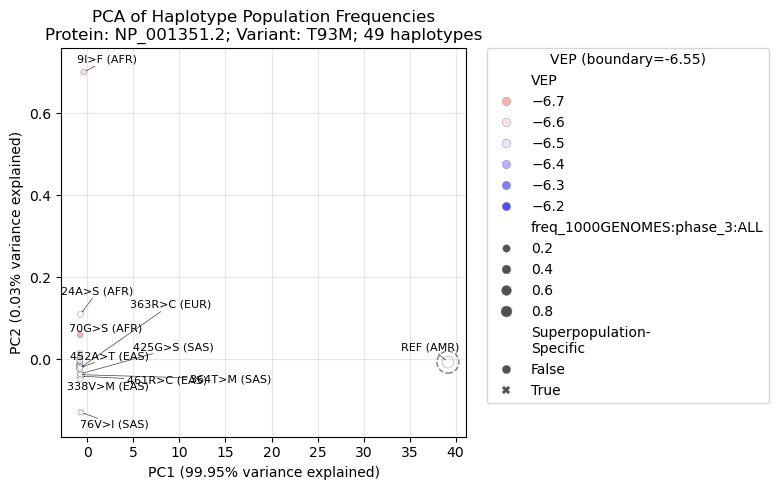

Variance explained by PC1: 99.95%
Variance explained by PC2: 0.03%
Total variance explained: 99.98%


In [104]:
freq_cols = [col for col in variant_data.columns if col.startswith('freq_')]
# superpops = variant_data['top_superpop'].unique().tolist()
# freq_cols = [col for col in freq_cols if col.endswith(tuple(superpops))]


# Run PCA on the population frequency data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(variant_data.set_index('haplotype').loc[:,freq_cols].fillna(0))

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], 
                      index=variant_data['haplotype'].tolist()
                      ).merge(variant_data, 
                              left_index=True, 
                              right_on='haplotype'
                              ).set_index('haplotype')
# Color by VEP
pca_df['Top\nSuperpopulation'] = pca_df['top_superpop'].str.split(':').str[-1]
pca_df['Superpopulation-\nSpecific'] = pca_df['nonzero_superpop_freqs']==1

pca_df.sort_values(['Top\nSuperpopulation','VEP'],inplace=True)
# Apply MinMax scaling to normalize VEP scores between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
pca_df['VEP\n(normalized)'] = 1- scaler.fit_transform(pca_df[['VEP']]).flatten()
# Plot the PCA results using seaborn
plt.figure(figsize=(8, 5))  # Increased width to accommodate legend outside
# Get the decision boundary value from the data if available
if 'decision_boundary' in pca_df.columns:
    decision_boundary = pca_df['decision_boundary'].iloc[0]
else:
    # Use a default value around -6 based on the context
    decision_boundary = -6

# Calculate the range for the color palette normalization
vep_min = pca_df['VEP'].min()
vep_max = pca_df['VEP'].max()
# Ensure the decision boundary is in the middle
palette_range = (2*decision_boundary - vep_max, vep_max)

sns.scatterplot(data=pca_df, 
                x='PC1',
                y='PC2', 
                size="freq_1000GENOMES:phase_3:ALL",
                # size="VEP\n(normalized)",
                # sizes=(50, 200),
                # hue='Top\nSuperpopulation',
                # palette=utils.get_superpop_palette(),
                hue='VEP',
                palette="bwr_r",
                # palette=sns.diverging_palette(h_neg=10, h_pos=240, s=100, l=60, 
                #                               as_cmap=True, center="dark"),
                hue_norm=palette_range,  # Dynamically set the middle of the palette to the decision boundary
                style='Superpopulation-\nSpecific',
                alpha=0.85,
                edgecolor='grey',
                )
plt.title(f'PCA of Haplotype Population Frequencies\nProtein: {pca_df.iloc[0]["protein"]}; Variant: {pca_df.iloc[0]["mutant"]}; {pca_df.shape[0]} haplotypes')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)')

# Move legend outside the plot to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title=f"VEP (boundary={decision_boundary:.2f})")

# Add annotations with repel labels
from adjustText import adjust_text
# Create a list to store annotation objects
texts = []
label_topn = 10
pca_df.sort_values(["top_superpop_freq",'VEP'], ascending=False, inplace=True)
for i, (haplotype, row) in enumerate(pca_df.iterrows()):  # Annotate first 10 points
    if i > label_topn:
        break
    txt = haplotype.split(':')[-1]
    if 'top_superpop' in row.index:
        txt = f"{txt} ({row['top_superpop'].split(':')[-1]})"
    # Create annotation and add to list
    texts.append(plt.text(x=pca_df['PC1'].iloc[i], 
                          y=pca_df['PC2'].iloc[i], 
                          s=txt,
                          fontsize=8))

# Apply the repel algorithm to prevent overlapping labels
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5, alpha=.75), expand=(1.2, 3))

# Add a black ring around the reference haplotype
ref_data = pca_df.loc[pca_df.is_ref==True]
if len(ref_data) > 0:
    plt.scatter(
        ref_data['PC1'], 
        ref_data['PC2'], 
        s=250,  # Slightly larger than the largest point
        facecolors='none', 
        edgecolors='black', 
        linewidths=1,
        linestyle='--',
        alpha=.5,
        zorder=10  # Ensure it's drawn on top of other points
    )

plt.grid(alpha=0.3)
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()

# Print variance explained
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_[:2]):.2%}")


In [94]:
# Get proteins where VEP is 0
print(vep_df.loc[vep_df['VEP']==0]['protein'].nunique())

# Get proteins where VEP is NA
print(vep_df.loc[vep_df['VEP'].isna()]['protein'].nunique())

132
259
